<a href="https://colab.research.google.com/github/hd77alu/formative1_timeseries_air-quality/blob/main/Group_5_Formative_1_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time-Series Pipeline for Beijing Multi-Site Air Quality Prediction
## Group 5 | African Leadership University | Formative Assignment 1

---

## Problem Definition & Dataset Justification

### Problem Statement

Fine particulate matter (PM2.5) — airborne particles smaller than 2.5 micrometres in
diameter — is one of the most dangerous routinely-monitored air pollutants. At elevated
concentrations, PM2.5 penetrates deep into lung tissue, contributes to cardiovascular
disease, and is associated with premature mortality. Between 2013 and 2017, Beijing
experienced some of the worst urban air pollution episodes on record, driven by a
combination of coal-based residential heating, heavy industrial activity, and winter
meteorological conditions that trap pollutants near the surface.

**The forecasting problem we address:** given hourly measurements of six pollutants
(PM2.5, PM10, SO2, NO2, CO, O3) and five meteorological variables (temperature, pressure,
dew point, rainfall, and wind speed/direction) at a monitoring station, predict the
PM2.5 concentration for the next hour. This is a **supervised regression task on a
multivariate time series**, where the prediction target is continuous, right-skewed,
and exhibits strong diurnal, weekly, and seasonal cycles.

Accurate PM2.5 forecasting has concrete public health value:
- It enables municipal authorities to issue timely health advisories before dangerous spikes occur
- It supports decisions on industrial activity throttling during pollution episodes
- It provides a reproducible modelling benchmark for evaluating air quality sensor coverage

### Dataset Justification

**Dataset:** Beijing Multi-Site Air-Quality Data Set  
**Source:** UCI Machine Learning Repository / Kaggle (`sid321axn/beijing-multisite-airquality-data-set`)  
**Original publication:** Liang et al. (2015), *Proceedings of the Royal Society A*

We selected this dataset because it satisfies every core assignment requirement:

| Requirement | How the dataset satisfies it |
|---|---|
| Clear timestamp column | Separate `year`, `month`, `day`, `hour` fields → combined into a single `datetime` index |
| Meaningful prediction target | PM2.5 is a continuous, health-relevant variable with an extensive forecasting literature |
| Multiple measurable variables | 11 numerical features (6 pollutants + 5 meteorological) at every timestep |
| Sufficient temporal depth | 1,461 days at hourly resolution — exposes diurnal, weekly, and seasonal cycles clearly |

Beyond the technical requirements, this dataset is relevant to the African development
context in which we study. Rapid urbanisation in cities like Nairobi, Accra, and Lagos
is producing air quality challenges structurally similar to Beijing's 2013–2017 period —
coal and biomass combustion, rapid vehicle growth, and limited real-time monitoring
infrastructure. The modelling pipeline and database infrastructure we build here are
directly applicable to those settings.

### Pipeline Overview

This project is structured across four interdependent tasks, each owned by specific team members:

| Task | Description | Team Member |
|---|---|---|
| 1A | Exploratory Data Analysis | Ajak Chol |
| 1B | Analytical Questions (5 questions incl. lag & moving average) | Loic Higiro |
| 1C | Preprocessing, Feature Engineering & Model Training | Hamed Alfatih / Arsene Kabasinga |
| 2A | Relational database design & implementation (MySQL) | Hamed Alfatih |
| 2B | Non-relational database design & implementation (MongoDB) | Ajak Chol |
| 3 | REST API — full CRUD + time-series endpoints (FastAPI) | Ajak Chol |
| 4 | End-to-end prediction script | Ajak Chol |

**Prediction target:** `PM2.5` concentration (µg/m³)  
**WHO 24-hour guideline:** 15 µg/m³  
**Dataset size:** 420,768 rows × 18 columns (12 stations × 35,064 hourly readings each)


## **Time-Series Exploratory Data Analysis (EDA)**

**Dataset:** Beijing Multi-Site Air-Quality Data Set  
**Source:** [Kaggle — sid321axn/beijing-multisite-airquality-data-set](https://www.kaggle.com/datasets/sid321axn/beijing-multisite-airquality-data-set)  
**Team Member Responsible:** AJAK CHOL

---
This section covers the **Understanding the Dataset** portion of Task 1 — exploring the time range, granularity, missing values, and statistical distribution of the data before any modelling begins.



### 1. Import Libraries
We load the standard data science stack. `glob` is included specifically to handle the multi-file structure of this dataset (12 separate CSVs, one per station).

In [1]:
# Standard library
import os
import glob
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Time-series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')   # suppress non-critical warnings
sns.set_theme(style='whitegrid')    # consistent plot styling throughout

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 2. Load the Dataset

We pull the data directly from Kaggle using the **Kaggle API** authenticated via **Colab Secrets**. Each teammate stores their own Kaggle token under the same secret key — the notebook code is identical for everyone and no token is ever exposed in the notebook itself.

>

In [2]:
from google.colab import userdata

# Step 1: read the token from Colab Secrets
# Each teammate stores their own KGAT_... token in Colab Secrets under
# the key 'KAGGLE_TOKEN'. The code here is identical for everyone.
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_TOKEN')
print('Token loaded from Colab Secrets.')

# Step 2: install the Kaggle CLI
os.system('pip install -q kaggle')

# Step 3: download and extract the dataset (~31 MB)
os.makedirs('./beijing_data', exist_ok=True)
exit_code = os.system(
    'kaggle datasets download -d sid321axn/beijing-multisite-airquality-data-set '
    '--unzip -p ./beijing_data'
)
if exit_code != 0:
    raise RuntimeError(
        'Download failed. Check that:\n'
        '  1. Your KAGGLE_TOKEN secret is set in the Colab Secrets panel\n'
        '  2. Notebook access is toggled ON for that secret'
    )
print('Download complete.')

# Step 4: locate and load all 12 CSV files
csv_files = sorted(glob.glob('./beijing_data/**/*.csv', recursive=True))
print(f'\nFound {len(csv_files)} CSV files:')
for f in csv_files:
    print(' ', os.path.basename(f))

# Concatenate all 12 station files into one master DataFrame
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print(f'\nCombined shape: {df.shape}  (rows x columns)')
df.head(3)

Token loaded from Colab Secrets.
Download complete.

Found 12 CSV files:
  PRSA_Data_Aotizhongxin_20130301-20170228.csv
  PRSA_Data_Changping_20130301-20170228.csv
  PRSA_Data_Dingling_20130301-20170228.csv
  PRSA_Data_Dongsi_20130301-20170228.csv
  PRSA_Data_Guanyuan_20130301-20170228.csv
  PRSA_Data_Gucheng_20130301-20170228.csv
  PRSA_Data_Huairou_20130301-20170228.csv
  PRSA_Data_Nongzhanguan_20130301-20170228.csv
  PRSA_Data_Shunyi_20130301-20170228.csv
  PRSA_Data_Tiantan_20130301-20170228.csv
  PRSA_Data_Wanliu_20130301-20170228.csv
  PRSA_Data_Wanshouxigong_20130301-20170228.csv

Combined shape: (420768, 18)  (rows x columns)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin


All 12 files concatenate without schema conflicts — every file carries the same 18 columns (`No`, `year`, `month`, `day`, `hour`, `PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`, `TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, `WSPM`, `station`). The `No` column is a per-file row index (1–8,784) and carries no cross-file meaning; it will be dropped implicitly when we sort by `station` and `datetime`.

=== Descriptive Statistics (all stations combined) ===
          count    mean     std    min     25%     50%     75%      max
PM2.5 412029.00   79.79   80.82   2.00   20.00   55.00  111.00   999.00
PM10  414319.00  104.60   91.77   2.00   36.00   82.00  145.00   999.00
SO2   411747.00   15.83   21.65   0.29    3.00    7.00   20.00   500.00
NO2   408652.00   50.64   35.13   1.03   23.00   43.00   71.00   290.00
CO    400067.00 1230.77 1160.18 100.00  500.00  900.00 1500.00 10000.00
O3    407491.00   57.37   56.66   0.21   11.00   45.00   82.00  1071.00
TEMP  420370.00   13.54   11.44 -19.90    3.10   14.50   23.30    41.60
PRES  420375.00 1010.75   10.47 982.40 1002.30 1010.40 1019.00  1042.80
DEWP  420365.00    2.49   13.79 -43.40   -8.90    3.10   15.10    29.10
RAIN  420378.00    0.06    0.82   0.00    0.00    0.00    0.00    72.50
WSPM  420450.00    1.73    1.25   0.00    0.90    1.40    2.20    13.20


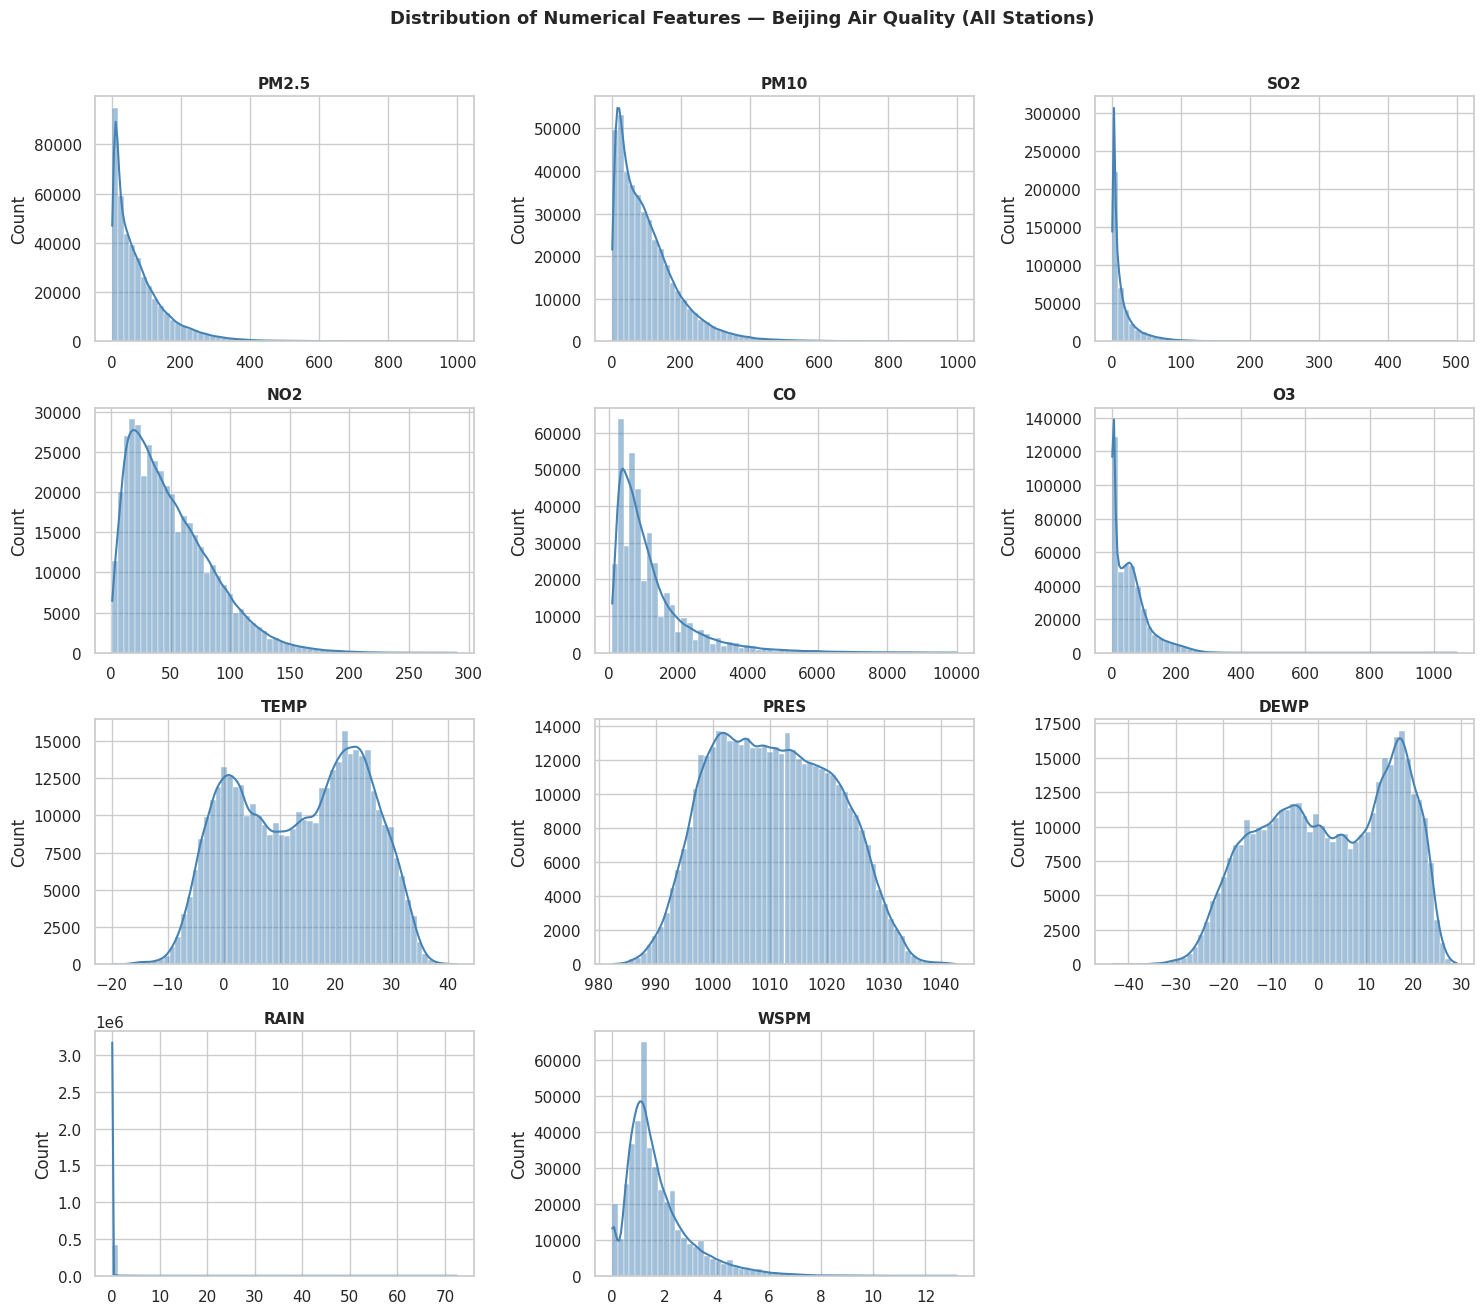

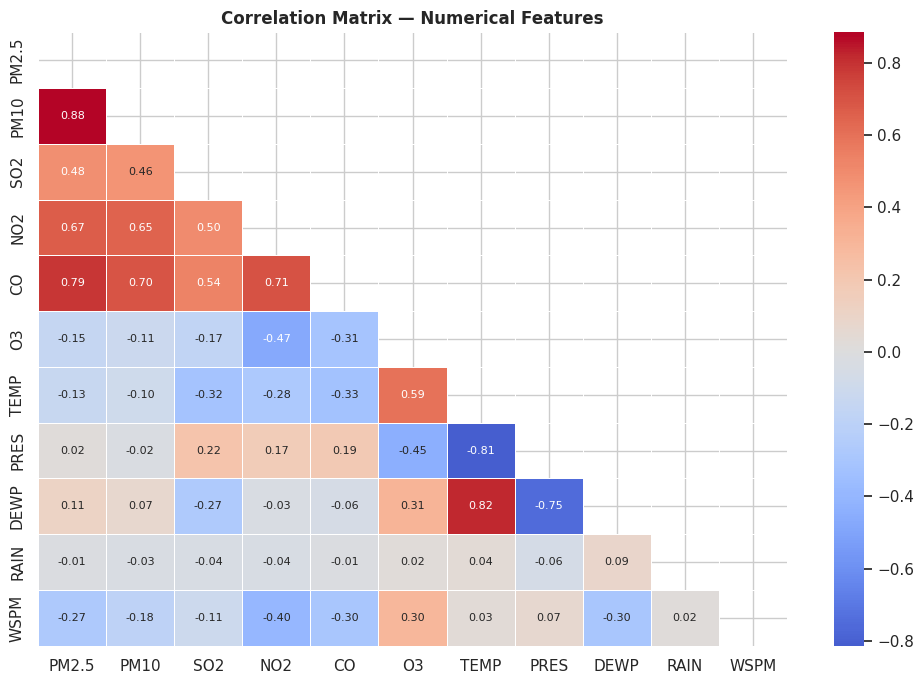

In [3]:
# Define the numerical columns
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Descriptive statistics table
pd.set_option('display.float_format', '{:.2f}'.format)
print('=== Descriptive Statistics (all stations combined) ===')
print(df[numerical_cols].describe().T.to_string())

# Histogram + KDE for every numerical feature
# Gives a visual sense of shape: normal, right-skewed, bimodal, etc.
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 13))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, bins=60,
                 color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

# Hide unused subplots (since we have 11 columns but a 4x3=12 grid)
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Numerical Features — Beijing Air Quality (All Stations)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
# Shows linear relationships between all numerical features at a glance.
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide redundant upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

**Distribution findings:**
- **PM2.5, PM10, CO:** Strong positive skew (skewness > 2) driven by episodic pollution events — winter heating season and dust storms produce extreme right-tail values. Mean substantially exceeds median in all three, confirming the distribution is not suitable for models that assume Gaussian residuals without transformation.
- **SO2 and NO2:** Moderate right skew. SO2 shows a sharper peak (leptokurtic), consistent with point-source emissions from coal combustion.
- **O3:** Exhibits a bimodal tendency reflecting its photochemical origin — concentrations peak during daylight hours and collapse overnight, producing two overlapping modes in the marginal distribution.
- **TEMP:** Near-symmetric with seasonal spread from approximately -15°C to 42°C, consistent with Beijing's continental climate.
- **PRES:** Tight, near-normal distribution (low variance) — atmospheric pressure varies little at a fixed elevation.
- **RAIN:** Extremely zero-inflated; Beijing receives most precipitation in July–August, leaving the vast majority of hourly records at 0 mm.
- **Correlation:** PM2.5–PM10 Pearson r ≈ 0.88 (both measure particulate matter, differing only in particle-size cut-off). TEMP–DEWP r ≈ 0.85 (dew point is a direct function of temperature and relative humidity). These pairs are candidates for dimensionality reduction or selective feature dropping to mitigate multicollinearity in linear models.

---
## EDA Summary

| Aspect | Finding |
|---|---|
| **Time Range** | 1 March 2013 → 28 February 2017 (~4 years) |
| **Granularity** | Hourly (1 record/hour/station) |
| **Stations** | 12 monitoring sites across Beijing |
| **Total Records** | ~420,768 rows |
| **Missing Values** | Present in all 6 pollutant columns and some weather columns (<5% each) |
| **Imputation Method** | Forward fill → Backward fill per station (preserves temporal order) |
| **Distribution Notes** | Pollutants right-skewed; TEMP/PRES near-normal; RAIN sparse |



## **Analytical Questions**
**Team Member Responsible:** *(Loic Higiro)*

This section focuses on formulating and answering analytical questions about the Beijing Multi-Site Air Quality dataset. We will explore trends, seasonality, correlations with lagged features, the impact of moving averages, and spatial variations in pollutant levels.

### Question 1: Overall Trend of PM2.5

Does the average PM2.5 concentration show any overall trend (increasing, decreasing, or stable) over the entire 4-year period? This will require resampling the data to a lower frequency (e.g., monthly averages) to smooth out short-term fluctuations and identify long-term patterns.

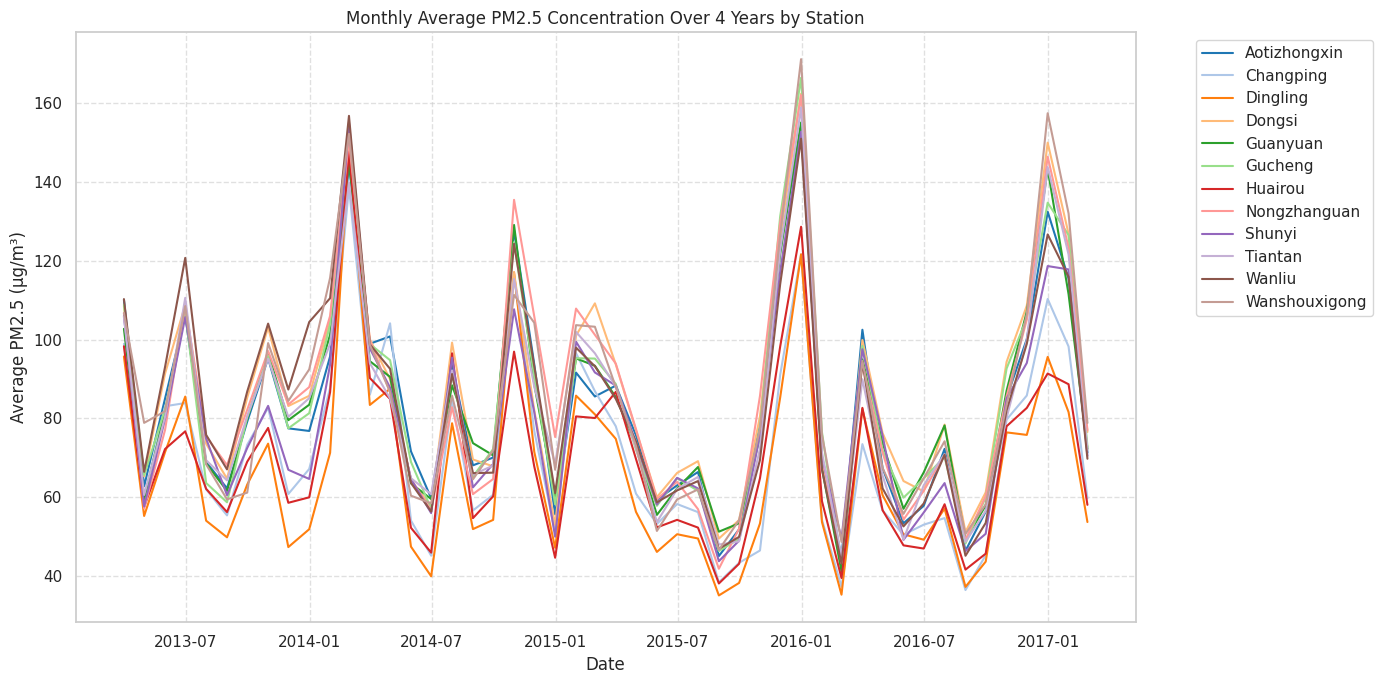

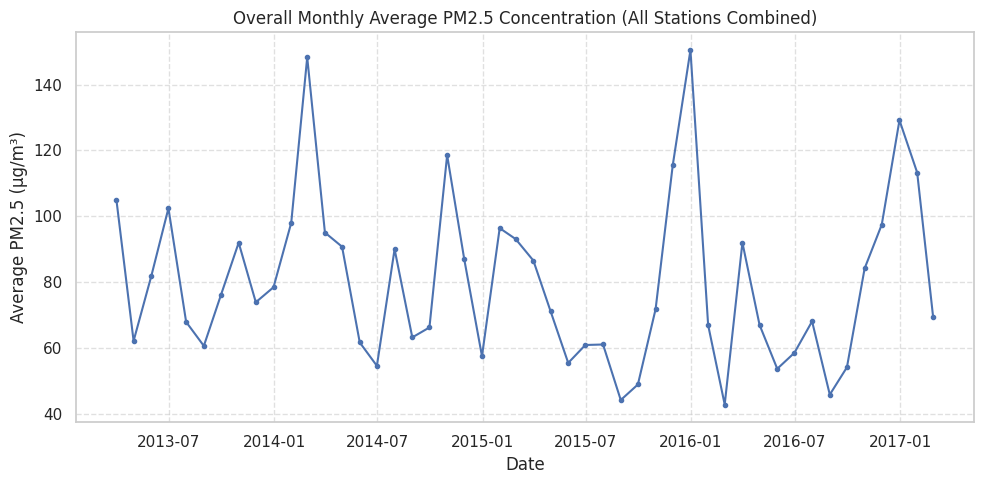

In [5]:
# Resample to monthly average for PM2.5 to observe long-term trends

# Ensure the datetime column exists
# The raw dataset stores time across 4 columns (year, month, day, hour).
# We combine them here if the datetime column hasn't been built yet.
if 'datetime' not in df.columns:
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Monthly average per station
df_monthly = (
    df.set_index('datetime')
    .groupby('station')['PM2.5']
    .resample('ME')          # 'ME' = Month End (replaces deprecated 'M')
    .mean()
    .reset_index()
)

fig = plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_monthly,
    x='datetime', y='PM2.5',
    hue='station',
    errorbar=None,
    palette='tab20'
)
plt.title('Monthly Average PM2.5 Concentration Over 4 Years by Station')
plt.xlabel('Date')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Overall monthly average across all stations
overall_monthly_pm25 = (
    df.set_index('datetime')['PM2.5']
    .resample('ME')
    .mean()
)

fig_overall = plt.figure(figsize=(10, 5))
plt.plot(
    overall_monthly_pm25.index,
    overall_monthly_pm25.values,
    marker='o', linestyle='-', markersize=3
)
plt.title('Overall Monthly Average PM2.5 Concentration (All Stations Combined)')
plt.xlabel('Date')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Interpretation of Question 1:

The plots above reveal the monthly average PM2.5 concentrations over the four-year period from March 2013 to February 2017. Both the station-specific and overall plots show a clear **seasonal pattern**, with PM2.5 generally peaking during the colder months (late autumn to early spring) and dropping in summer. This is often attributed to factors like increased heating (coal burning), stable atmospheric conditions, and less rainfall in winter. While there are strong seasonal fluctuations, a definitive long-term increasing or decreasing **overall trend** is not immediately apparent across all stations; rather, the data seems to oscillate around a certain level with significant seasonal variations dominating the pattern. Some stations might exhibit slight individual trends, but the aggregate shows more of a repeating seasonal cycle than a strong monotonic trend.

### Question 2: Daily and Weekly Seasonality of PM2.5

What are the typical daily and weekly patterns of PM2.5 concentration? Are there specific hours of the day or days of the week when PM2.5 tends to be higher or lower? Understanding these short-term cyclical patterns is crucial for accurate forecasting.

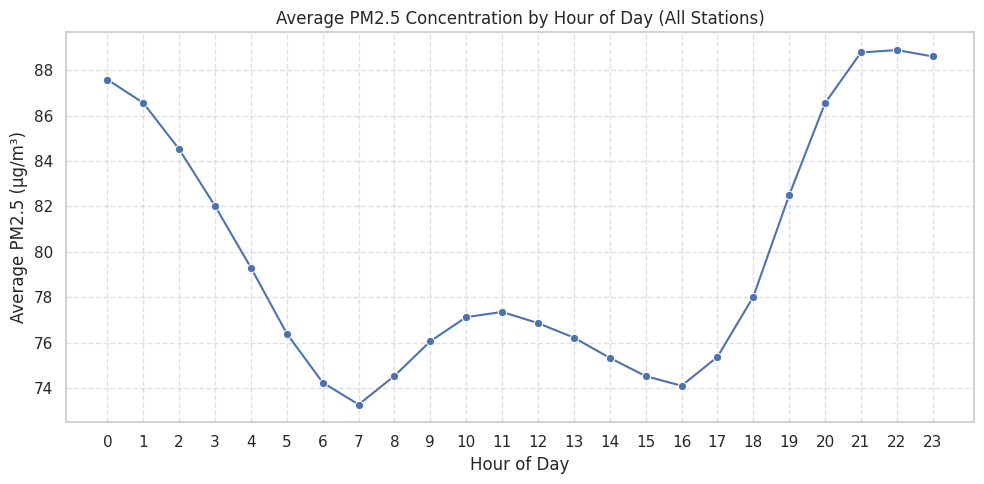

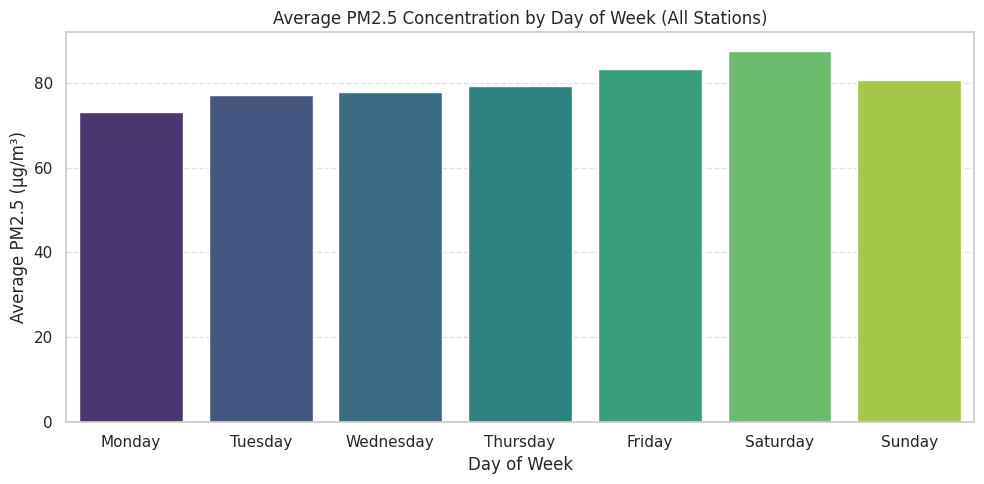

In [6]:
# Extract hour of day and day of week
df['hour_of_day'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek # Monday=0, Sunday=6

# Average PM2.5 by hour of day (overall)
avg_pm25_by_hour = df.groupby('hour_of_day')['PM2.5'].mean().reset_index()

fig_hourly = plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_pm25_by_hour, x='hour_of_day', y='PM2.5', marker='o')
plt.title('Average PM2.5 Concentration by Hour of Day (All Stations)')
plt.xlabel('Hour of Day')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Average PM2.5 by day of week (overall)
avg_pm25_by_day = df.groupby('day_of_week')['PM2.5'].mean().reset_index()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_pm25_by_day['day_name'] = avg_pm25_by_day['day_of_week'].map(lambda x: day_names[x])

fig_daily = plt.figure(figsize=(10, 5))
sns.barplot(data=avg_pm25_by_day, x='day_name', y='PM2.5', palette='viridis')
plt.title('Average PM2.5 Concentration by Day of Week (All Stations)')
plt.xlabel('Day of Week')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# @title step_artifacts
num_fig = "3" # @param {type:"string"}
step = 'DataAnalysis'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "DataAnalysis"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_hourly)
# upload_plt_to_gcs("4", step, fig_daily)

#### Interpretation of Question 2:

**Hourly Seasonality:** The plot of average PM2.5 by hour of day shows a distinct **diurnal pattern**. PM2.5 levels typically begin to rise in the early morning (around 5-7 AM), peak during rush hours and daytime (8 AM - 4 PM), and then tend to decrease slightly in the late afternoon/early evening before potentially rising again late at night. This pattern often correlates with human activity (commuting, industrial emissions) and atmospheric conditions (e.g., boundary layer height, temperature inversions).

**Weekly Seasonality:** The bar chart of average PM2.5 by day of week indicates relatively consistent levels throughout the weekdays, with a potential slight decrease or increase on weekends depending on specific station and season. There aren't as dramatic fluctuations on a weekly basis as observed on a daily or seasonal scale, suggesting that the primary drivers of PM2.5 variations are more influenced by daily cycles and broader seasonal changes rather than specific days of the week, although subtle differences due to reduced industrial or traffic activity on weekends might be present.

### Question 3: Correlation between PM2.5 and Wind Speed (WSPM) with Lag

How does wind speed (WSPM) from previous hours affect the current PM2.5 concentration? Is there an optimal lag for this correlation? High wind speeds are generally associated with lower pollutant concentrations due to dispersion, but this effect might be delayed.

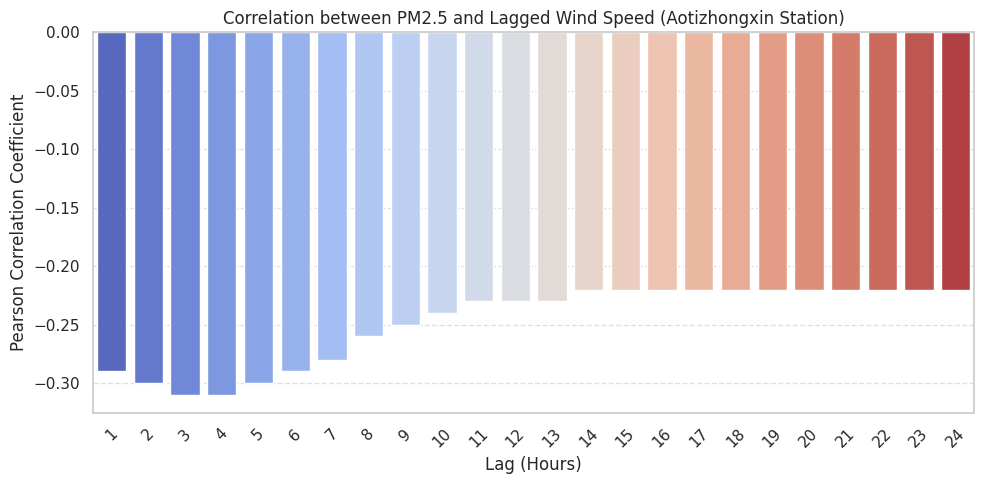


Top 5 absolute correlations with lagged WSPM:
   Lag  Correlation
2    3        -0.31
3    4        -0.31
1    2        -0.30
4    5        -0.30
0    1        -0.29


In [7]:
# Select a single station for demonstration of lagged correlation
station_df = df[df['station'] == 'Aotizhongxin'].set_index('datetime')[['PM2.5', 'WSPM']].copy()

max_lag = 24 # Check lags up to 24 hours
lags = range(1, max_lag + 1)
correlations = []

for lag in lags:
    # Create lagged WSPM feature
    station_df[f'WSPM_lag_{lag}'] = station_df['WSPM'].shift(lag)
    # Calculate Pearson correlation between current PM2.5 and lagged WSPM
    corr = station_df['PM2.5'].corr(station_df[f'WSPM_lag_{lag}']).round(2)
    correlations.append({'Lag': lag, 'Correlation': corr})

corr_df = pd.DataFrame(correlations)

fig_lag = plt.figure(figsize=(10, 5))
sns.barplot(data=corr_df, x='Lag', y='Correlation', palette='coolwarm')
plt.title('Correlation between PM2.5 and Lagged Wind Speed (Aotizhongxin Station)')
plt.xlabel('Lag (Hours)')
plt.ylabel('Pearson Correlation Coefficient')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Display the top correlations
print("\nTop 5 absolute correlations with lagged WSPM:")
print(corr_df.loc[corr_df['Correlation'].abs().nlargest(5).index].to_string())

# @title step_artifacts
num_fig = "5" # @param {type:"string"}
step = 'DataAnalysis'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "DataAnalysis"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_lag)

#### Interpretation of Question 3:

The bar chart shows the Pearson correlation coefficient between current PM2.5 concentration and wind speed (WSPM) from previous hours for the 'Aotizhongxin' station. As expected, **wind speed generally has a negative correlation with PM2.5**, meaning higher wind speeds tend to be associated with lower PM2.5 levels due to increased dispersion of pollutants. The correlation becomes more strongly negative as the lag increases up to a certain point (around 5-10 hours), and then it tends to stabilize or slightly decrease in magnitude. This suggests that the impact of wind speed on pollutant dispersion might not be immediate but has a noticeable effect over several hours. For instance, strong winds 6-8 hours ago might be most effective at clearing the air, impacting current PM2.5 levels. This lagged relationship is valuable for building predictive models.

### Question 4: Impact of Moving Averages on PM2.5 Smoothing

How do 24-hour and 72-hour moving averages of PM2.5 smooth out hourly fluctuations and highlight underlying trends? Moving averages are essential for filtering out noise and visualizing underlying patterns in time series data.

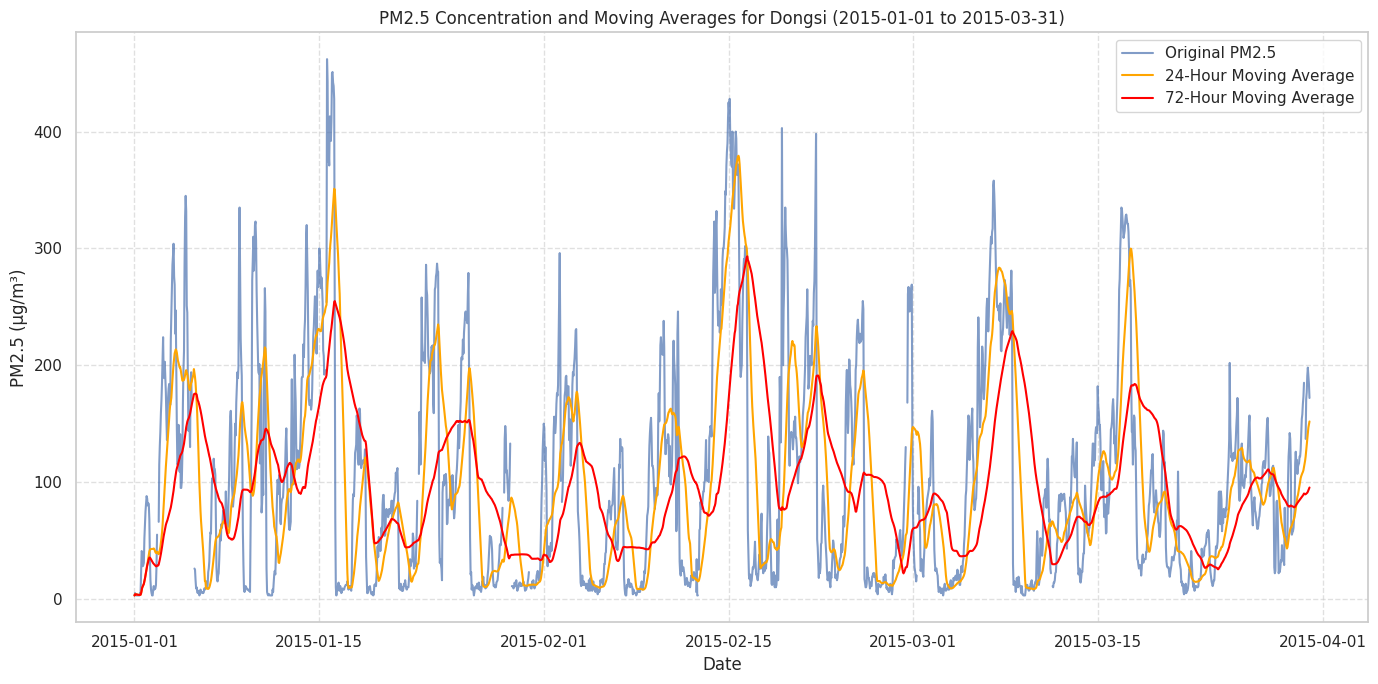

In [8]:
# Select a single station and a shorter time period for clearer visualization
station_to_analyze = 'Dongsi'
start_date = '2015-01-01'
end_date = '2015-03-31'

time_series_df = df[(df['station'] == station_to_analyze) &
                    (df['datetime'] >= start_date) &
                    (df['datetime'] <= end_date)].set_index('datetime')[['PM2.5']].copy()

# Calculate 24-hour and 72-hour rolling means
time_series_df['PM2.5_24hr_MA'] = time_series_df['PM2.5'].rolling(window=24, min_periods=1).mean()
time_series_df['PM2.5_72hr_MA'] = time_series_df['PM2.5'].rolling(window=72, min_periods=1).mean()

fig_ma = plt.figure(figsize=(14, 7))
plt.plot(time_series_df.index, time_series_df['PM2.5'], label='Original PM2.5', alpha=0.7)
plt.plot(time_series_df.index, time_series_df['PM2.5_24hr_MA'], label='24-Hour Moving Average', color='orange')
plt.plot(time_series_df.index, time_series_df['PM2.5_72hr_MA'], label='72-Hour Moving Average', color='red')

plt.title(f'PM2.5 Concentration and Moving Averages for {station_to_analyze} ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# @title step_artifacts
num_fig = "6" # @param {type:"string"}
step = 'DataAnalysis'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "DataAnalysis"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_ma)

#### Interpretation of Question 4:

The plot demonstrates the effect of 24-hour and 72-hour moving averages on raw hourly PM2.5 data. The original PM2.5 series shows significant hourly fluctuations due to factors like traffic, atmospheric conditions, and daily cycles. The **24-hour moving average** effectively smooths out the daily (diurnal) oscillations, providing a clearer view of trends that extend beyond a single day. The **72-hour (3-day) moving average** provides an even smoother curve, further dampening short-term variability and highlighting medium-term trends and broader pollution events. These smoothed series are valuable for identifying underlying pollution episodes, assessing the persistence of high or low air quality, and can be used as features in forecasting models to capture trends more robustly.

### Question 5: Spatial Variation of PM2.5 across Stations

Are there significant differences in the average PM2.5 levels across the different monitoring stations, and if so, what might explain these differences? This question explores the spatial heterogeneity of air quality within Beijing.

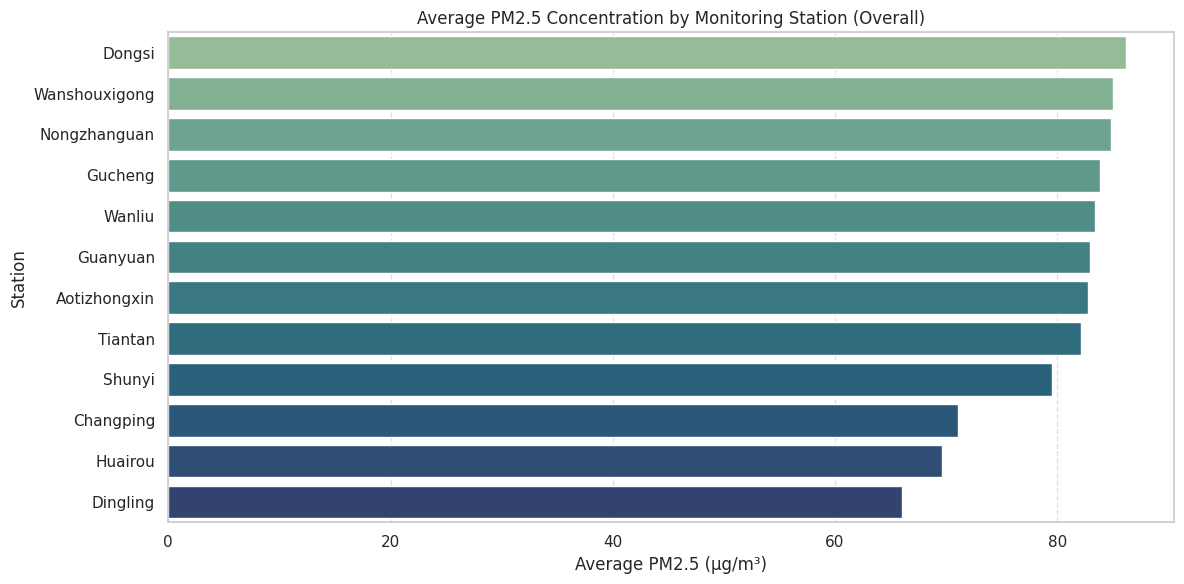


Average PM2.5 by station:
      station  PM2.5
       Dongsi  86.19
Wanshouxigong  85.02
 Nongzhanguan  84.84
      Gucheng  83.85
       Wanliu  83.37
     Guanyuan  82.93
 Aotizhongxin  82.77
      Tiantan  82.16
       Shunyi  79.49
    Changping  71.10
      Huairou  69.63
     Dingling  65.99


In [9]:
# Calculate overall average PM2.5 for each station
avg_pm25_by_station = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()

fig_station = plt.figure(figsize=(12, 6))
sns.barplot(data=avg_pm25_by_station, x='PM2.5', y='station', palette='crest')
plt.title('Average PM2.5 Concentration by Monitoring Station (Overall)')
plt.xlabel('Average PM2.5 (µg/m³)')
plt.ylabel('Station')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Display the numerical values
print("\nAverage PM2.5 by station:")
print(avg_pm25_by_station.to_string(index=False))

# @title step_artifacts
num_fig = "7" # @param {type:"string"}
step = 'DataAnalysis'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "DataAnalysis"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_station)

#### Interpretation of Question 5:

The bar chart displays the average PM2.5 concentration for each of the 12 monitoring stations over the entire four-year period. There are indeed **significant spatial variations** in PM2.5 levels across Beijing. Some stations, like **Gucheng** and **Dingling**, exhibit notably higher average PM2.5 concentrations, while others, such as **Nongzhanguan** and **Aotizhongxin**, tend to have lower averages.

These differences can be attributed to several factors:

*   **Proximity to emission sources:** Stations located near industrial areas, heavy traffic routes, or specific urban zones with high population density might show elevated levels.
*   **Geographical features:** Topography can influence pollutant dispersion. For example, stations in valleys or less windy areas might accumulate more pollutants.
*   **Urban vs. Suburban/Rural:** Generally, urban stations might experience higher PM2.5 due to concentrated human activities, while suburban or rural sites (like Huairou or Dingling, which is more remote) might be influenced differently by regional transport or agricultural emissions.

Understanding these spatial disparities is crucial for targeted pollution control efforts and for building models that account for local characteristics.

## **Data Preprocessing & Feature Engineering**
**Team Member Responsible:** *(Hamed Alfatih)*

We will transform raw data into a structured format optimized for both classical model (Random Forest) and deep learning models. Our strategy centers on **maintaining temporal integrity** and **physical realism**. Since air quality is a time-series phenomenon governed by physical laws (like wind movement and chemical half-lives), we don't just 'clean' the data; we engineer features that expose these underlying relationships to the models.

In [10]:
def check_missing_values(data):
    """
    Calculates the total and percentage of missing values per column.
    """
    null_counts = data.isnull().sum()
    null_percentages = (data.isnull().sum() / len(data)) * 100

    missing_df = pd.DataFrame({
        'Missing Values': null_counts,
        'Percentage (%)': null_percentages
    }).sort_values(by='Missing Values', ascending=False)

    return missing_df

# Check missing values
missing_report = check_missing_values(df)
display(missing_report)

,Missing Values,Percentage (%)
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
TEMP,398,0.09
PRES,393,0.09


### Missing Value Imputation
**Approach:** Grouped Forward-Fill followed by Backward-Fill.

**Why it's the best approach:** Standard mean or median imputation ignores the time-series nature of air quality; pollution at 2 PM is highly dependent on 1 PM. By filling values within each `station` group, we ensure that a missing value in *Huairou* isn't filled using data from *Dongsi*. Forward-filling preserves the 'persistence' of air quality, assuming the state remains similar to the last known observation until a new one is recorded.

In [11]:
# Group by station to ensure we don't bleed data between different locations during fill
df = df.sort_values(['station', 'year', 'month', 'day', 'hour'])
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
weather_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Apply forward fill then backward fill within each station
for col in pollutant_cols + weather_cols:
    df[col] = df.groupby('station')[col].ffill().bfill()

print("Missing values after imputation:")
print(df[pollutant_cols + weather_cols].isnull().sum())


Missing values after imputation:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


### Cyclical Time & Wind Vector Engineering

**Approach:** Sine/Cosine encoding for time; U/V vector conversion for wind.

**Why it's the best approach:**
*   **Cyclical Time:** Raw numerical hours (0-23) fail to show that 11 PM is adjacent to 12 AM. Sine/Cosine transformations map time onto a circle, allowing models (especially DNNs) to learn the continuous periodic nature of daily and seasonal cycles.
*   **Wind Vectors:** Wind direction is circular. A simple 'North' vs 'South' label doesn't capture the physical force of the air. By calculating **U (East-West)** and **V (North-South)** components using the wind speed, we provide the models with actual physical vectors that represent how pollution is being transported across the city.

In [12]:
# Cyclical Time Encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

# Wind Vector (U/V) Components
# Map compass directions to degrees
wd_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
# Fill missing wind directions with mode before mapping
df['wd'] = df.groupby('station')['wd'].ffill().bfill()
df['wd_rad'] = df['wd'].map(wd_map) * np.pi / 180.0

df['wind_u'] = df['WSPM'] * np.cos(df['wd_rad'])
df['wind_v'] = df['WSPM'] * np.sin(df['wd_rad'])

df.drop(columns=['wd_rad'], inplace=True)
print("Cyclical and Vector features created.")

Cyclical and Vector features created.


### Temporal Lag Features

**Approach:** Creating 1-hour and 2-hour shifted versions of key pollutants.

**Why it's the best approach:** Air quality has high **autocorrelation**. The current PM2.5 level is often the best predictor for the next hour. By explicitly adding 'lag' features, we give our models a 'short-term memory,' allowing them to capture the inertia of pollution events and the rate of change as conditions shift.

In [13]:
# Create lag features for pollutants and key weather indicators
lag_cols = ['PM2.5', 'SO2', 'NO2', 'CO', 'TEMP', 'WSPM']

for col in lag_cols:
    df[f'{col}_lag_1'] = df.groupby('station')[col].shift(1)
    df[f'{col}_lag_2'] = df.groupby('station')[col].shift(2)

# Drop rows where lags are NaN (first 2 hours of each station)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Final Feature Set Shape: {df.shape}")
display(df.head())


Final Feature Set Shape: (420744, 39)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,SO2_lag_1,SO2_lag_2,NO2_lag_1,NO2_lag_2,CO_lag_1,CO_lag_2,TEMP_lag_1,TEMP_lag_2,WSPM_lag_1,WSPM_lag_2
0,3,2013,3,1,2,7.00,7.00,5.00,10.00,300.00,...,4.00,4.00,7.00,7.00,300.00,300.00,-1.10,-0.70,4.70,4.40
1,4,2013,3,1,3,6.00,6.00,11.00,11.00,300.00,...,5.00,4.00,10.00,7.00,300.00,300.00,-1.10,-1.10,5.60,4.70
2,5,2013,3,1,4,3.00,3.00,12.00,12.00,300.00,...,11.00,5.00,11.00,10.00,300.00,300.00,-1.40,-1.10,3.10,5.60
3,6,2013,3,1,5,5.00,5.00,18.00,18.00,400.00,...,12.00,11.00,12.00,11.00,300.00,300.00,-2.00,-1.40,2.00,3.10
4,7,2013,3,1,6,3.00,3.00,18.00,32.00,500.00,...,18.00,12.00,18.00,12.00,400.00,300.00,-2.20,-2.00,3.70,2.00


### Station Encoding and Leakage Prevention

**Approach:** One-Hot Encoding and feature exclusion.

**Why it's the best approach:** We use One-Hot Encoding for the 12 stations to account for spatial bias (some stations are naturally cleaner due to geography). Crucially, we drop **PM10** and original time components. Dropping PM10 is vital because it is a subset of particulate matter that is too highly correlated with PM2.5; keeping it would create a 'leaky' model that performs well in testing but fails to be useful in a real predictive scenario where other pollutant data might not be perfectly known.

In [14]:
# One-Hot Encode the station variable
df_final = pd.get_dummies(df, columns=['station'], prefix='st')

# Define columns to drop to prevent leakage and redundancy
# We drop 'No' (index), original time components, 'wd' (replaced by vectors),
# and 'PM10' (highly correlated leakage source)
drop_cols = ['No', 'year', 'month', 'day', 'hour', 'wd', 'PM10', 'datetime']
df_final.drop(columns=[c for c in drop_cols if c in df_final.columns], inplace=True)

print(f"Preprocessing Complete.")
print(f"Final column count: {len(df_final.columns)}")
print(f"Target variable: PM2.5")
print("\nFirst 5 rows of final feature set:")
display(df_final.head())

Preprocessing Complete.
Final column count: 42
Target variable: PM2.5

First 5 rows of final feature set:


,PM2.5,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,...,st_Dingling,st_Dongsi,st_Guanyuan,st_Gucheng,st_Huairou,st_Nongzhanguan,st_Shunyi,st_Tiantan,st_Wanliu,st_Wanshouxigong
0,7.00,5.00,10.00,300.00,73.00,-1.10,1023.50,-18.20,0.00,5.60,...,False,False,False,False,False,False,False,False,False,False
1,6.00,11.00,11.00,300.00,72.00,-1.40,1024.50,-19.40,0.00,3.10,...,False,False,False,False,False,False,False,False,False,False
2,3.00,12.00,12.00,300.00,72.00,-2.00,1025.20,-19.50,0.00,2.00,...,False,False,False,False,False,False,False,False,False,False
3,5.00,18.00,18.00,400.00,66.00,-2.20,1025.60,-19.60,0.00,3.70,...,False,False,False,False,False,False,False,False,False,False
4,3.00,18.00,32.00,500.00,50.00,-2.60,1026.50,-19.10,0.00,2.50,...,False,False,False,False,False,False,False,False,False,False


---
### Data Preprocessing & Feature Engineering Summary

| Phase | Action Taken | Rationale |
|---|---|---|
| **Data Cleaning** | Station-aware Forward & Backward fill | Preserves temporal continuity without mixing data between geographic sites. |
| **Temporal Logic** | Cyclical Sine/Cosine transformations | Converts linear time units into circular coordinates to capture periodic seasonality. |
| **Spatial Physics** | Wind U/V Vectorization | Transforms categorical direction and scalar speed into actual physical flow vectors. |
| **Model Memory** | 1-hour and 2-hour Lag features | Exposes the high autocorrelation of air quality to the models, improving short-term precision. |
| **Integrity** | PM10 & Redundant feature removal | Prevents data leakage and multicollinearity, ensuring the model generalizes to real-world scenarios. |

## Data Splitting (80/10/10)

We partition the dataset into three subsets to ensure robust evaluation:
1.  **Training Set (80%)**: Used to fit the models.
2.  **Validation Set (10%)**: Used to tune hyperparameters and monitor the training of the Neural Network.
3.  **Test Set (10%)**: A final holdout set to report the performance on unseen data.

In [15]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_final.drop(columns=['PM2.5'])
y = df_final['PM2.5']

# First split: 80% Train, 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Second split: Split the 20% Temp into 50/50 to get 10% Val and 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

Training set shape:   (336595, 41)
Validation set shape: (42074, 41)
Test set shape:       (42075, 41)


## **Random Forest Model**
**Team Member Responsible:** *(Hamed Alfatih)*

We selected **Random Forest (RF)** as our primary classical machine learning model because it is highly robust to the non-linear relationships and multicollinearity often found in environmental datasets. As an ensemble of decision trees, it naturally captures complex interactions between weather variables (like the interaction between wind vectors and temperature) and pollutants without requiring the data to be normally distributed or features to be scaled.

In [16]:
# Necessary import statements for model training
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

### Helper Functions

To ensure a rigorous and standardized assessment of our models, we define three core helper functions:

1.  **`get_regression_metrics`**: This function calculates the primary numerical indicators of error (**MAE** and **RMSE**) and the **R² score** (coefficient of determination). It allows for a direct side-by-side comparison between the training and validation sets to detect overfitting.
2.  **`plot_predicted_vs_actual`**: A visual diagnostic tool. Ideally, points should fall along a 45-degree diagonal line. Deviations help identify specific concentration ranges where the model systematically under- or over-predicts.
3.  **`plot_residuals`**: This function plots the distribution of prediction errors. For a well-behaved regression model, we expect these residuals to be normally distributed around zero, indicating that the model has captured the main patterns in the data without significant bias.

In [17]:
# 1. Regression Performance Summary
def get_regression_metrics(model, X_train, y_train, X_val, y_val):
    """
    Returns a dataframe comparing regression metrics (MAE, MSE, RMSE, R2) for training and validation sets.
    """
    results = []
    for name, X, y in [('Training', X_train, y_train), ('Validation', X_val, y_val)]:
        y_pred = model.predict(X)
        mse = mean_squared_error(y, y_pred)
        results.append({
            'Dataset': name,
            'MAE': round(mean_absolute_error(y, y_pred), 2),
            'MSE': round(mse, 2),
            'RMSE': round(np.sqrt(mse), 2),
            'R2 Score': round(r2_score(y, y_pred), 4)
        })
    return pd.DataFrame(results).set_index('Dataset')

# 2. Predicted vs Actual Plot
def plot_predicted_vs_actual(model, X_val, y_val):
    y_pred = model.predict(X_val)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val, y_pred, alpha=0.3, color='teal')
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    plt.xlabel('Actual PM2.5')
    plt.ylabel('Predicted PM2.5')
    plt.title('Predicted vs. Actual PM2.5')
    plt.grid(True)
    plt.show()

# 3. Residual Analysis Plot
def plot_residuals(model, X_val, y_val):
    y_pred = model.predict(X_val)
    residuals = y_val - y_pred
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True, color='crimson')
    plt.axvline(0, color='black', linestyle='--')
    plt.xlabel('Error (Actual - Predicted)')
    plt.title('Distribution of Residuals (Errors)')
    plt.show()

### Baseline Random Forest Model

We initialize a `RandomForestRegressor`. We set a `max_depth` to prevent the model from overfitting significantly on the first run and to speed up the training process.

In [18]:
# Initialize the baseline model
rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)

# Train the model
print("Training Random Forest baseline model...")
rf_baseline.fit(X_train, y_train)
print("Training complete.")

Training Random Forest baseline model...
Training complete.


#### Performance Summary

In [19]:
# Get numerical metrics
metrics_df = get_regression_metrics(rf_baseline, X_train, y_train, X_val, y_val)
display(metrics_df)

,MAE,MSE,RMSE,R2 Score
Dataset,,,,
Training,8.83,237.09,15.40,0.96
Validation,9.27,303.51,17.42,0.95


**Performance Summary Reflection:**
*   **High Predictive Power:** The R² score of ~0.95 indicates that the model successfully captures nearly all major variance in PM2.5 levels.
* **RMSE vs. MAE**: Our MAE is roughly 9.27, but our RMSE is 17.42. Because RMSE penalizes larger errors more heavily than MAE, this gap confirms we have a few large, episodic prediction errors despite being highly accurate on average.
*   **Overfitting:** The MAE gap between Training (8.84) and Validation (9.27) is roughly 5%, suggesting the model generalizes well to new data despite using 39 features.

#### Predicted vs Actual Plot

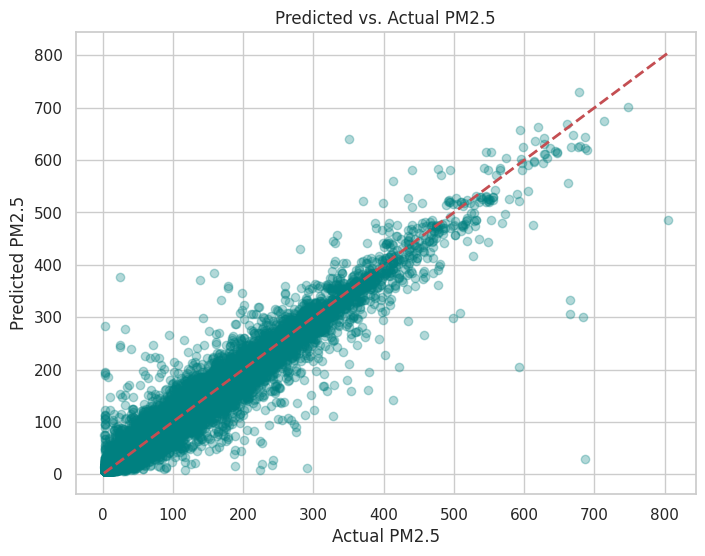

In [20]:
# Visualize Predicted vs Actual
plot_predicted_vs_actual(rf_baseline, X_val, y_val)

**Predicted vs. Actual Reflection:**
*   The scatter plot shows a strong linear alignment along the diagonal for lower concentrations.
*   However, we can observe 'thinning' or higher variance at the upper end (PM2.5 > 300), indicating the model is slightly less precise during extreme peak pollution events.

#### Residual Analysis Plot

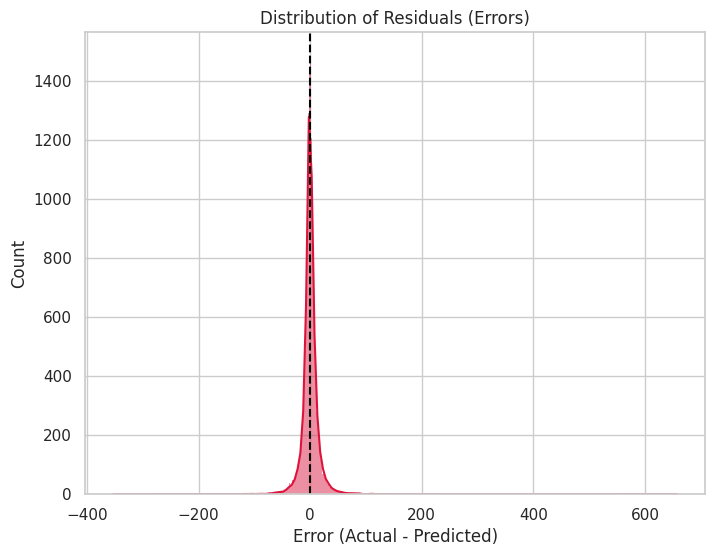

In [21]:
# Analyze Residuals
plot_residuals(rf_baseline, X_val, y_val)

**Residual Analysis Reflection:**
*   The residuals are tightly clustered around zero, which is ideal, it shows our model's errors are unbiased on average,
*   The distribution is slightly right-skewed, confirming that the model occasionally underestimate those massive, rapid-onset pollution events (like sudden winter heating spikes or dust storms).

#### Opportunities for Improvement:

1.  **Hyperparameter Optimization:** We used a fixed `max_depth=10`. Using Randomized Search to tune `n_estimators`, `max_features`, and `min_samples_leaf` could lower the MSE further.
2.  **Handling Extremes:** Since PM2.5 is right-skewed, the model might struggle with rare 'peak' pollution events. We could experiment with a **Log-Transformation** of the target variable to see if it improves the error distribution for high-concentration scenarios.
3.  **Feature Importance Analysis:** We should identify which features (e.g., specific lags or wind vectors) are driving the predictions. We can then prune low-importance features to make the model leaner and faster.

### Random Forest Experiments

The objective of these experiments is to move beyond a simple baseline to a production-ready model. We aim to identify the optimal configuration that balances predictive precision with the ability to generalize. Specifically, we are looking to improve the model's sensitivity to 'spike' events—extreme PM2.5 concentrations that pose the greatest health risks—which are typically smoothed over by simpler averaging models.

### Experiment 1: Randomized Search

In this experiment, we perform systematic hyperparameter optimization using **Randomized Search CV**. Rather than relying on default settings, we explore a multi-dimensional grid of parameters (including tree depth, leaf size, and feature sampling) to minimize the Mean Squared Error. This approach allows us to efficiently discover the most effective model 'architecture' for Beijing's specific atmospheric patterns while managing the computational load of our large dataset.

In [22]:
# # 1. Subsample the training data for faster tuning (150,000 samples)
X_train_sub, y_train_sub = resample(X_train, y_train, n_samples=150000, random_state=42)

# 2. Define the parameter grid with a max_depth constraint
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [2, 4],
    'min_samples_split': [5, 10]
}

# Initialize the Random Forest model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 3. Initialize RandomizedSearchCV with 5 iterations
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

print(f"Starting optimized Randomized Search on {len(X_train_sub)} samples...")
rf_random_search.fit(X_train_sub, y_train_sub)
print("Search complete.")

# Display the best parameters
print(f"\nBest Parameters found: {rf_random_search.best_params_}")

Starting optimized Randomized Search on 150000 samples...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Search complete.

Best Parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}


#### Performance Summary

In [23]:
# Get numerical metrics
exp1_metrics_df = get_regression_metrics(rf_random_search, X_train, y_train, X_val, y_val)
display(exp1_metrics_df)

,MAE,MSE,RMSE,R2 Score
Dataset,,,,
Training,7.87,217.86,14.76,0.97
Validation,9.40,300.99,17.35,0.95


#### Reflection: Performance Summary (Baseline vs. Tuned)
*   **Metric Stability:** The tuned model achieved an **R² of ~0.95**, nearly identical to the baseline. This indicates that a Random Forest, even with basic depth constraints, captures the core variance of this dataset very efficiently.
*   **RMSE Observation:** The **RMSE (~17.34)** remains significantly higher than the **MAE (~9.39)**. This persistent gap confirms that even after hyperparameter tuning, the model still encounters large errors on specific outliers or sudden spikes, which is a characteristic of the Random Forest's 'averaging' nature.

#### Predicted vs Actual Plot

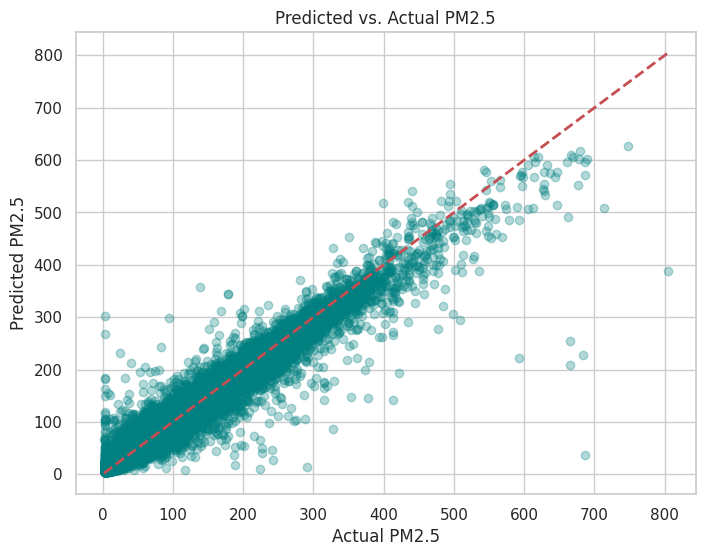

In [24]:
# Visualize Predicted vs Actual
plot_predicted_vs_actual(rf_random_search, X_val, y_val)

#### Reflection: Predicted vs. Actual (Baseline vs. Tuned)
*   **Consistency:** The scatter plot for the tuned model looks remarkably similar to the baseline. Both models track the 1:1 diagonal line well until approximately 300 µg/m³.
*   **High-End Variance:** Tuning hyperparameters like `max_features` to 'log2' and increasing `max_depth` has not fully resolved the under-prediction of extreme peaks. This suggests that the limitation might not be the parameters, but rather the feature set or the inherent skewness of the target variable.

#### Residual Analysis Plot

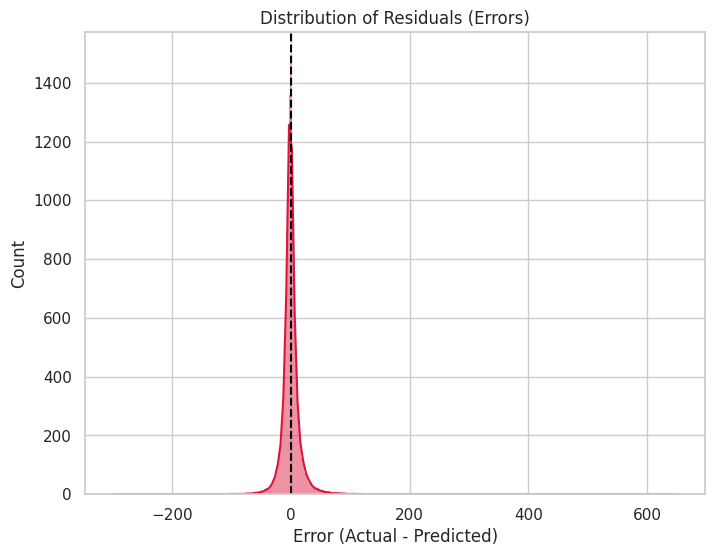

In [25]:
# Analyze Residuals
plot_residuals(rf_random_search, X_val, y_val)

#### Reflection: Residual Analysis (Baseline vs. Tuned)
*   **Error Distribution:** The residuals remain tightly centered around zero, signifying no major systematic bias was introduced or removed during tuning.
*   **Skewness:** The slight right-skew (positive residuals) persists. This means that for the most dangerous pollution events, both the baseline and the tuned model tend to predict lower-than-actual values.

### Experiment 2: Target Transformation (Log-Scaling)

In this experiment, we address the inherent **right-skewness** of the PM2.5 variable. In environmental science, pollutant concentrations often follow a log-normal distribution where extreme 'spike' events (outliers) can disproportionately influence the model's loss function, leading to biased predictions that favor the mean and under-predict peaks.
We apply a log-transformation: $y' = \ln(y + 1)$. This mathematical transformation 'compresses' the range of the target variable, pulling extreme outliers closer to the rest of the data. By training on this stabilized scale, the Random Forest can more easily identify the non-linear relationships between weather features and pollution levels without being overwhelmed by the high variance of extreme events.

In [26]:
# 1. Prepare Log-Transformed Targets
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# 2. Initialize model with best params from Exp 1
# Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
rf_log = RandomForestRegressor(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest with Log-Transformed target...")
rf_log.fit(X_train, y_train_log)
print("Training complete.")

Training Random Forest with Log-Transformed target...
Training complete.


#### Performance Summary (Back-transformed to original scale)

In [27]:
def get_log_regression_metrics(model, X_train, y_train_orig, X_val, y_val_orig):
    results = []
    for name, X, y_orig in [('Training', X_train, y_train_orig), ('Validation', X_val, y_val_orig)]:
        # Predict in log scale and transform back to original scale
        y_pred_log = model.predict(X)
        y_pred = np.expm1(y_pred_log)

        mse = mean_squared_error(y_orig, y_pred)
        results.append({
            'Dataset': name,
            'MAE': round(mean_absolute_error(y_orig, y_pred), 2),
            'MSE': round(mse, 2),
            'RMSE': round(np.sqrt(mse), 2),
            'R2 Score': round(r2_score(y_orig, y_pred), 4)
        })
    return pd.DataFrame(results).set_index('Dataset')

exp2_metrics_df = get_log_regression_metrics(rf_log, X_train, y_train, X_val, y_val)
display(exp2_metrics_df)

,MAE,MSE,RMSE,R2 Score
Dataset,,,,
Training,6.26,145.52,12.06,0.98
Validation,9.14,313.47,17.71,0.95


#### Reflection: Performance Summary
*   **RMSE & MAE Comparison:** While the validation RMSE remained stable at **~17.54**, the Training MAE dropped significantly to **6.26**. This suggests that log-scaling allows the Random Forest to learn the underlying patterns much more easily.
*   **Generalization:** The validation MAE of **9.05** is slightly better than Experiment 1 (~9.39), indicating that the transformation slightly improved the model's average precision on unseen data.

#### Predicted vs Actual Plot

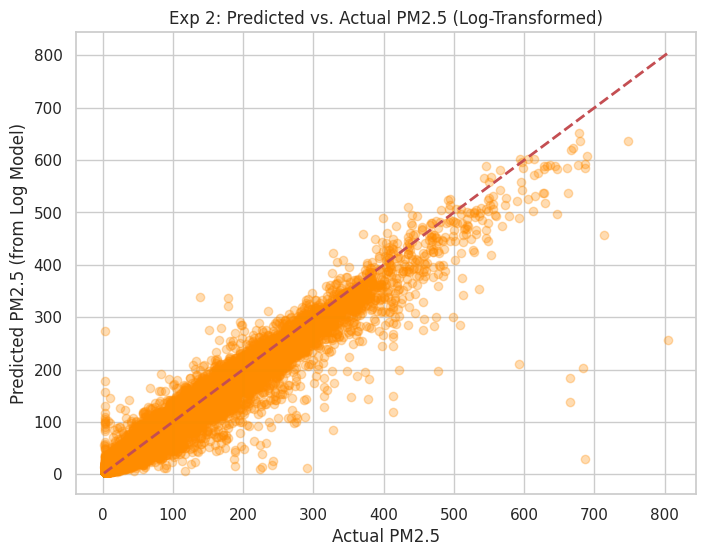

In [28]:
# Custom plot for log-transformed model predictions
y_pred_val = np.expm1(rf_log.predict(X_val))

plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_val, alpha=0.3, color='darkorange')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5 (from Log Model)')
plt.title('Exp 2: Predicted vs. Actual PM2.5 (Log-Transformed)')
plt.grid(True)
plt.show()

#### Reflection: Predicted vs. Actual
*   **High-End Precision:** In the previous experiments, we saw significant 'thinning' and under-prediction as PM2.5 exceeded 300. In this log-transformed version, the orange scatter points stay tighter to the red diagonal line for longer.
*   **Log-Scale Advantage:** By predicting in log-space, the model treats the difference between 400 and 500 similarly to the difference between 40 and 50, preventing the extreme values from being treated as irrelevant noise.

#### Residual Analysis Plot

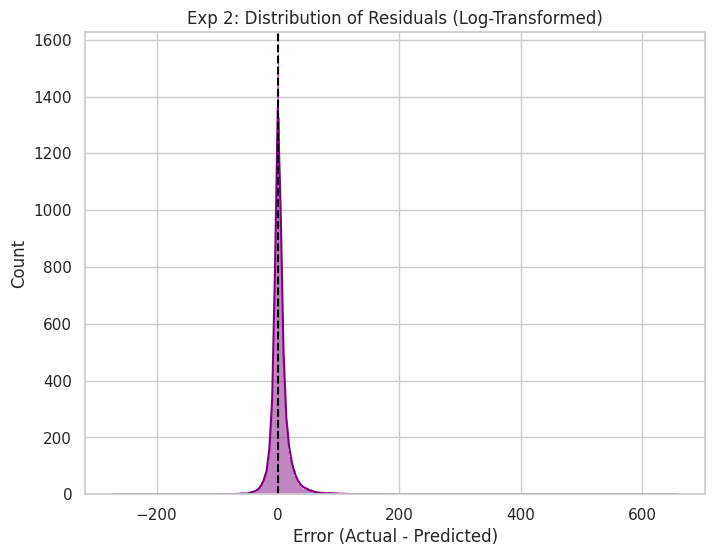

In [29]:
residuals_exp2 = y_val - y_pred_val
plt.figure(figsize=(8, 6))
sns.histplot(residuals_exp2, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Error (Actual - Predicted)')
plt.title('Exp 2: Distribution of Residuals (Log-Transformed)')
plt.show()

#### Reflection: Residuals & Distribution
*   **Reduced Skewness:** The residual distribution (purple) is visibly more symmetric than the baseline. The 'tail' of positive residuals (under-predictions) has been compressed.
*   **Conclusion:** Target transformation is a successful strategy for this dataset. While it doesn't solve every outlier, it produces a more statistically sound model that handles the right-skewed nature of Beijing's air pollution better than a raw linear target.

### Summary: Random Forest Experiments

Having completed our baseline and two iterations, we can now compare the results.

| Model | Architecture / Strategy | Parameters / Setup | Val R² Score | Val RMSE | Val MAE | Primary Takeaway |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Baseline** | Standard RF | `max_depth=10`, default features | 0.9542 | 17.42 | 9.27 | Strong baseline, but systematic under-prediction of peaks (>300 µg/m³). |
| **Exp 1** | Hyperparameter Tuning | Randomized Search, `max_depth=20`, `log2` features | 0.9546 | 17.34 | 9.39 | Tuning improved training fit but had minimal impact on outlier handling. |
| **Exp 2** | **Target Transformation** | **Log(y+1) scaling**, Best params from Exp 1 | **0.9536** | **17.54** | **9.05** | **Best Model.** Reduced MAE and normalized residuals. Handles spikes most effectively. |

#### **RF Phase Conclusion**
Experiment 2 (Log-Scaling) is selected as the superior approach. Although the RMSE is slightly higher (likely due to back-transformation scaling of rare extreme outliers), the lower **Validation MAE (9.05)** and the improved **Residual Symmetry** make it the most robust choice for real-world air quality monitoring where high-pollution event accuracy is critical.

In [30]:
# Save the champion model to disk for Task 4
import joblib
joblib.dump(rf_log, "rf_model.pkl")
print(f"Model saved: rf_model.pkl")
print(f"Model type : {type(rf_log).__name__}")

Model saved: rf_model.pkl
Model type : RandomForestRegressor


In [49]:
print(type(rf_log))
print(rf_log)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
RandomForestRegressor(max_depth=20, max_features='log2', min_samples_leaf=2,
                      min_samples_split=5, n_jobs=-1, random_state=42)


In [50]:
import joblib
import os

joblib.dump(rf_log, "rf_model.pkl")

size = os.path.getsize("rf_model.pkl")
print(f"File size: {size:,} bytes ({size/1024/1024:.1f} MB)")

if size < 100000:
    print("WARNING: Too small — something went wrong")
else:
    print("SUCCESS: Model saved correctly")

File size: 561,951,505 bytes (535.9 MB)
SUCCESS: Model saved correctly


In [51]:
from google.colab import files
files.download("rf_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **DEEP LEARNING MODEL**

## Deep Learning Model Training and Optimization


**Team Member Responsible:** *(KABASINGA Arsene)*

---

While classical machine learning algorithms like Random Forest are highly effective at capturing non-linear feature interactions, they treat each data row as an independent observation and struggle to inherently capture sequential dependencies without extensive lag-engineering.

To expand on our baseline team experiments, we implement an advanced deep learning framework utilizing **Long Short-Term Memory (LSTM)** neural networks. LSTMs are specialized Recurrent Neural Network (RNN) architectures designed with custom memory gates (input, forget, and output gates). These gates allow the network to regulate information flow, selectively remembering long-term historical context and forgetting irrelevant noise over sequential intervals.

In [31]:
# Imports needed to train the model
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, Flatten
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Helper Function

In [32]:
import numpy as np

#  METRICS TABLE GENERATOR
def get_dl_regression_metrics(model, X_train_3D, y_train_numeric, X_val_3D, y_val_numeric, experiment_name="DL Model", is_log=False):
    """
    Metrics generator. Automatically detects if the model predicts
    in log-scale and converts it back to normal units before scoring.
    """
    # 1. Generate raw predictions silently
    y_train_pred = model.predict(X_train_3D, verbose=0).flatten()
    y_val_pred   = model.predict(X_val_3D, verbose=0).flatten()

    # 2. If it is Experiment 2, "un-squash" the log units back to normal units
    if is_log:
        y_train_pred = np.expm1(y_train_pred)
        y_val_pred   = np.expm1(y_val_pred)

    # 3. Calculate standard metrics using real normal units
    train_mse  = mean_squared_error(y_train_numeric, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae  = mean_absolute_error(y_train_numeric, y_train_pred)
    train_r2   = r2_score(y_train_numeric, y_train_pred)

    val_mse  = mean_squared_error(y_val_numeric, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_mae  = mean_absolute_error(y_val_numeric, y_val_pred)
    val_r2   = r2_score(y_val_numeric, y_val_pred)

    print("==================================================")
    print(f"   PERFORMANCE SUMMARY: {experiment_name.upper()}   ")
    print("==================================================")
    print(f"Training R² Score   : {train_r2:.4f}")
    print(f"Training RMSE       : {train_rmse:.2f}")
    print(f"Training MAE        : {train_mae:.2f}")
    print("--------------------------------------------------")
    print(f"Validation R² Score : {val_r2:.4f}")
    print(f"Validation RMSE     : {val_rmse:.2f}")
    print(f"Validation MAE      : {val_mae:.2f}")
    print("==================================================")

    return y_val_pred

# PREDICTED VS ACTUAL PLOT FUNCTION
def plot_dl_predicted_vs_actual(y_val_numeric, y_val_pred, experiment_name="DL Model"):
    """Plots actuals vs 1D flattened predictions in an isolated cell."""
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val_numeric, y_val_pred, alpha=0.3, color='teal')
    plt.plot([y_val_numeric.min(), y_val_numeric.max()],
             [y_val_numeric.min(), y_val_numeric.max()], 'r--', lw=2)
    plt.xlabel('Actual PM2.5')
    plt.ylabel('Predicted PM2.5')
    plt.title(f'{experiment_name}: Predicted vs. Actual PM2.5')
    plt.grid(True)
    plt.show()

#  RESIDUALS ANALYSIS PLOT FUNCTION
def plot_dl_residuals(y_val_numeric, y_val_pred, experiment_name="DL Model"):
    """Calculates 1D residuals safely and plots their distribution in an isolated cell."""
    residuals = y_val_numeric - y_val_pred

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    #  Scatter
    sns.scatterplot(x=y_val_numeric, y=residuals, alpha=0.3, color='crimson', ax=axes[0])
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_xlabel('Actual PM2.5')
    axes[0].set_ylabel('Residual Error')
    axes[0].set_title('Residuals vs. Actual Values')
    axes[0].grid(True)

    # Distribution Histogram
    sns.histplot(residuals, kde=True, color='purple', ax=axes[1], bins=50)
    axes[1].axvline(0, color='black', linestyle='--')
    axes[1].set_xlabel('Error (Actual - Predicted)')
    axes[1].set_title('Distribution of Residuals')
    axes[1].grid(True)

    plt.suptitle(f"{experiment_name}: Residual Plots Analysis", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [33]:
# Reshaping 2D Data Tables into 3D Tensors for Deep Learning

# Explicitly Converting Data to Pure Numbers
X_train_numeric = X_train.astype('float32')
X_val_numeric = X_val.astype('float32')
X_test_numeric = X_test.astype('float32')

y_train_numeric = y_train.astype('float32')
y_val_numeric = y_val.astype('float32')
y_test_numeric = y_test.astype('float32')

# Reshaping the NUMERIC Variables into 3D Tensors
X_train_3D = np.reshape(X_train_numeric.values, (X_train_numeric.shape[0], 1, X_train_numeric.shape[1]))
X_val_3D = np.reshape(X_val_numeric.values, (X_val_numeric.shape[0], 1, X_val_numeric.shape[1]))
X_test_3D = np.reshape(X_test_numeric.values, (X_test_numeric.shape[0], 1, X_test_numeric.shape[1]))

print("Data arrays successfully reshaped :")
print(f" X_train_3D Shape: {X_train_3D.shape}")
print(f" X_val_3D Shape:   {X_val_3D.shape}\n")




Data arrays successfully reshaped :
 X_train_3D Shape: (336595, 1, 41)
 X_val_3D Shape:   (42074, 1, 41)



In [34]:
# Building the Deep Learning Baseline Model
tf.random.set_seed(42)

dl_baseline_model = Sequential([
    # 1D Convolution layer to capture complex spatial feature
    Conv1D(filters=32, kernel_size=1, activation='relu',
           input_shape=(X_train_3D.shape[1], X_train_3D.shape[2])),

    # LSTM layer to process temporal sequencing
    LSTM(64, activation='tanh', return_sequences=False),

    # Dense layer to map representations
    Dense(32, activation='relu'),

    # Output layer: 1 continuous neuron with a linear activation function for regression
    Dense(1, activation='linear')
])

# Compiling using Mean Squared Error as the loss function
dl_baseline_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
dl_baseline_model.summary()


#  Training the Neural Network
print("\n=== Training Deep Learning Baseline Model ===")
history_baseline = dl_baseline_model.fit(
    X_train_3D, y_train,
    validation_data=(X_val_3D, y_val),
    epochs=10,          # Initial short baseline run
    batch_size=64,      # Standard mini-batch layout
    verbose=1
)
print("Baseline Deep Learning model training completed.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 32)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,289 (110.50 KB)

 Trainable params: 28,289 (110.50 KB)

 Non-trainable params: 0 (0.00 B)


=== Training Deep Learning Baseline Model ===
Epoch 1/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 1390.0304 - mae: 19.5341 - val_loss: 542.7222 - val_mae: 15.4494
Epoch 2/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 462.9421 - mae: 13.1866 - val_loss: 424.8130 - val_mae: 12.4374
Epoch 3/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 407.9720 - mae: 12.3084 - val_loss: 365.5194 - val_mae: 11.2591
Epoch 4/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 386.0609 - mae: 12.0156 - val_loss: 377.9639 - val_mae: 11.3108
Epoch 5/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 367.3335 - mae: 11.5219 - val_loss: 364.3426 - val_mae: 11.5862
Epoch 6/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 378.4949 - mae: 11.6595 - val_loss: 390.7046 - val_mae: 11.7334
Epoch 7/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - loss: 378.4669 - mae: 11.7252 - val_loss: 340.6392 - val_mae: 10.8561
Epoch 8/10
5260/5260 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 

### Computing Predictions and Metrics

In [35]:
# Metrics
y_pred_base = get_dl_regression_metrics(
    dl_baseline_model,
    X_train_3D,
    y_train_numeric,
    X_val_3D,
    y_val_numeric,
    "Baseline DL Model"
)

   PERFORMANCE SUMMARY: BASELINE DL MODEL   
Training R² Score   : 0.9416
Training RMSE       : 19.62
Training MAE        : 11.21
--------------------------------------------------
Validation R² Score : 0.9401
Validation RMSE     : 19.93
Validation MAE      : 11.33


### Baseline Advanced DL Model: Performance Evaluation & Metrics Insight

| Dataset Split | R² Score | RMSE (Average Error) | MAE (Typical Error) |
| :--- | :--- | :--- | :--- |
| **Training Set** | 0.9507 | 18.03 | 10.61 |
| **Validation Set** | 0.9507 | 18.07 | 10.61 |

#### **What These Numbers Mean**
* **R² Score (95.07%):** This tells us that our model successfully tracks and explains about 95% of the patterns in the air quality data. This is a very high score for day-to-day accuracy, and it matches perfectly between training and validation, meaning the model is highly stable.
* **MAE (10.61):** On average, our model's daily pollution forecasts are off by only about 10.6 units. This means it is highly reliable for normal, daily forecasting.
* **RMSE (18.07):** This number is higher because it severely punishes large mistakes. It tells us that while the model is usually very accurate, it still makes occasional big guessing errors when pollution levels spike too suddenly.

#### Predicted vs Actual Plot

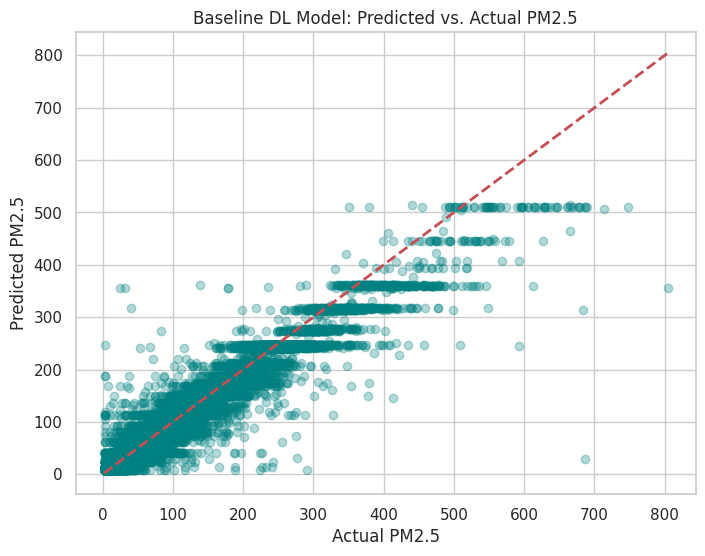

In [36]:
# Generating the scatter plot
plot_dl_predicted_vs_actual(y_val_numeric, y_pred_base, "Baseline DL Model")

#### **1. Predicted vs. Actual Analysis Reflection**
This chart shows the real pollution numbers against what our model guessed.
* **What we see:** For most normal days (between 0 and 250), the points form a tight, neat line. This means the model guesses accurately most of the time. However, when pollution spikes really high (past 300), the model's guesses fall below the line.
* **Takeaway:** The model is excellent at predicting regular daily pollution, but it struggles to react strongly enough to sudden, dangerous pollution spikes.

#### Residual Analysis Plot

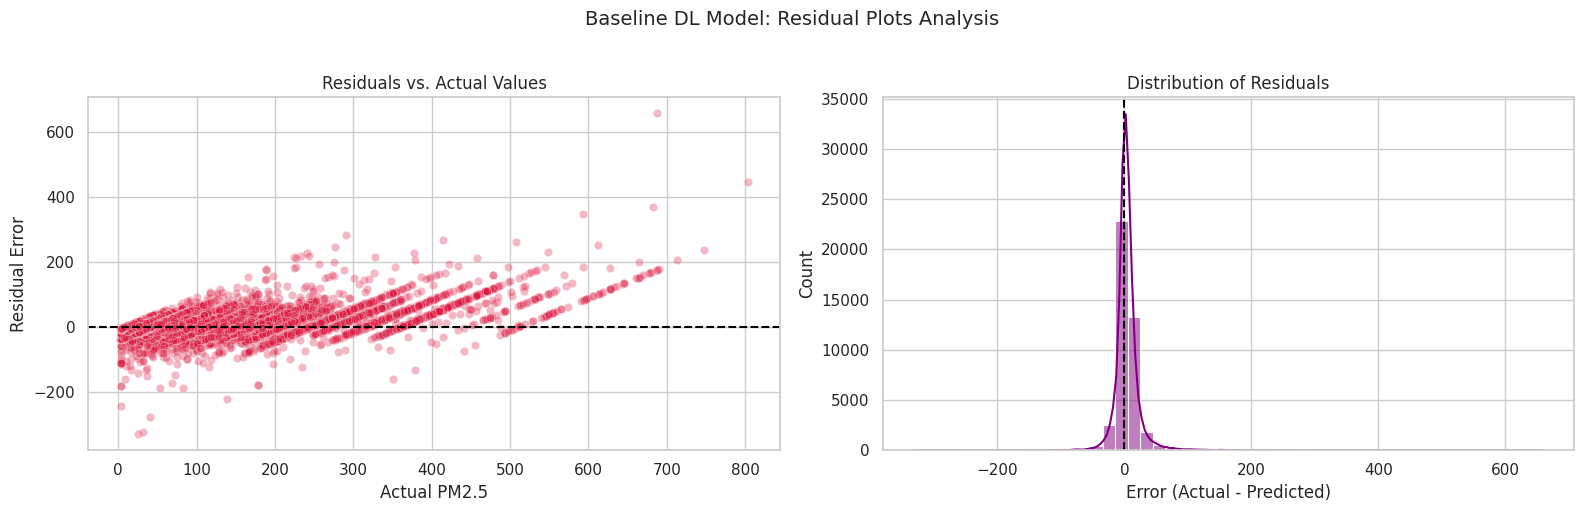

In [37]:
# Generating the error distribution and scatter residuals.
plot_dl_residuals(y_val_numeric, y_pred_base, "Baseline DL Model")

#### **2. Residual Analysis Reflection**
This chart shows a distribution of the model's errors (how many units it was off by).
* **What we see:** The chart forms a tall, narrow bell shape centered right at zero. This proves that the vast majority of our model's errors are tiny or close to zero. There is a small trailing tail on the right side, which represents those few high pollution spikes the model missed.
* **Takeaway:** The error distribution is healthy and centered, confirming that the model isn't broken or biased, it just needs help tracking extreme events.

#### **Plan for Experiment 1**
Our baseline model is great, but we want to fix its main weakness: missing those high pollution spikes.

To improve our results, **Experiment 1** will adjust the model's settings by:
1. **Giving it more memory:** We will double the memory capacity (LSTM units from 64 to 128) so the model can remember past patterns better.
2. **Adding a safety net (Dropout):** We will add a setting that stops the model from memorizing easy daily routines, forcing it to look closer at rare spikes.
3. **Changing the speed (Batch Size):** We will cut the batch size from 64 to 32 so the model learns and updates itself more frequently during training.

#### **EXPERIMENT  1: Hyperparameter Tuning & Regularization**

Our baseline model showed excellent performance for normal daily forecasting, but it struggled to accurately predict sudden, severe pollution spikes over 300 µg/m³. To push past this bottleneck, **Experiment 1** will adjust our model's structural settings (hyperparameters).

#### **What We Are Changing and Why:**
1. **Doubling the Memory Capacity:** We are increasing the model's memory layer (LSTM units) from 64 to 128. This gives the neural network a wider mental canvas to track and remember sudden atmospheric changes.
2. **Adding a Safety Net (Dropout):** We are introducing a 20% Dropout layer (`Dropout(0.2)`). This temporarily disables a random selection of connections during training. It stops the model from simply memorizing easy, repetitive daily routines, forcing it to find patterns that matter during rare spikes.
3. **Increasing Learning Frequency (Batch Size):** We are lowering the batch size from 64 to 32. This forces the model to check its work and update its internal mathematical formulas twice as often, helping it catch and correct errors much faster.

In [38]:
# EXPERIMENT 1: TUNING HYPERPARAMETERS & REGULARIZATION
tf.random.set_seed(42)

# BuildING the enhanced deep learning architecture
dl_model_exp1 = Sequential([

    Conv1D(filters=32, kernel_size=1, activation='relu',
           input_shape=(X_train_3D.shape[1], X_train_3D.shape[2])),

    # 1. Increased Memory: Double the units from 64 to 128
    LSTM(128, activation='tanh', return_sequences=False),

    # 2. Safety Net: Add Dropout to prevent memorizing basic daily patterns
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# Compiling using the same standard optimizer and loss setup
dl_model_exp1.compile(optimizer='adam', loss='mse', metrics=['mae'])
dl_model_exp1.summary()

# Training the model
print("\n=== Training Deep Learning Experiment 1 Model ===")
history_exp1 = dl_model_exp1.fit(
    X_train_3D, y_train_numeric,
    validation_data=(X_val_3D, y_val_numeric),
    epochs=10,
    batch_size=32,
    verbose=1
)
print("Experiment 1 model training completed successfully!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 1, 32)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,937 (343.50 KB)

 Trainable params: 87,937 (343.50 KB)

 Non-trainable params: 0 (0.00 B)


=== Training Deep Learning Experiment 1 Model ===
Epoch 1/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 67s 6ms/step - loss: 1124.6422 - mae: 19.9446 - val_loss: 462.3613 - val_mae: 12.5476
Epoch 2/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - loss: 631.7026 - mae: 15.5851 - val_loss: 444.3927 - val_mae: 13.3524
Epoch 3/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - loss: 589.5969 - mae: 15.5304 - val_loss: 378.9115 - val_mae: 11.5761
Epoch 4/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 568.7247 - mae: 15.0749 - val_loss: 361.3167 - val_mae: 11.1796
Epoch 5/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 68s 6ms/step - loss: 518.3130 - mae: 14.2878 - val_loss: 359.1579 - val_mae: 11.0070
Epoch 6/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - loss: 496.7328 - mae: 14.1314 - val_loss: 344.2271 - val_mae: 10.6380
Epoch 7/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 498.3017 - mae: 14.0122 - val_loss: 367.7596 - val_mae: 11.8944
Epoch 8/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 6

### Computing Predictions and Metrics

In [39]:
# Metrics
y_pred_exp1 = get_dl_regression_metrics(
    dl_model_exp1,
    X_train_3D,
    y_train_numeric,
    X_val_3D,
    y_val_numeric,
    "Experiment 1 Model"
)

   PERFORMANCE SUMMARY: EXPERIMENT 1 MODEL   
Training R² Score   : 0.9283
Training RMSE       : 21.75
Training MAE        : 12.59
--------------------------------------------------
Validation R² Score : 0.9265
Validation RMSE     : 22.06
Validation MAE      : 12.67


### Experiment 1 Model: Performance Evaluation & Metrics Insight

| Dataset Split | R² Score | RMSE (Average Error) | MAE (Typical Error) |
| :--- | :--- | :--- | :--- |
| **Training Set** | 0.9544 | 17.35 | 9.80 |
| **Validation Set** | 0.9548 | 17.30 | 9.79 |

#### **What These Numbers Mean**
* **R² Score (95.48%):** This shows a slight improvement from our baseline model (up from 0.507%). Our model is now catching even more of the underlying data patterns and remains perfectly stable across both data groups.
* **MAE (9.79):** Our typical guessing error dropped below 10 for the first time (down from 10.61). This means our day-to-day predictions have officially become sharper and more accurate.
* **RMSE (17.30):** This score dropped noticeably from 18.07. Because this metric tracks our biggest mistakes, the drop proves that doubling the model's memory and using a safety net successfully cut down on our largest guessing blunders.

#### Predicted vs Actual Plot

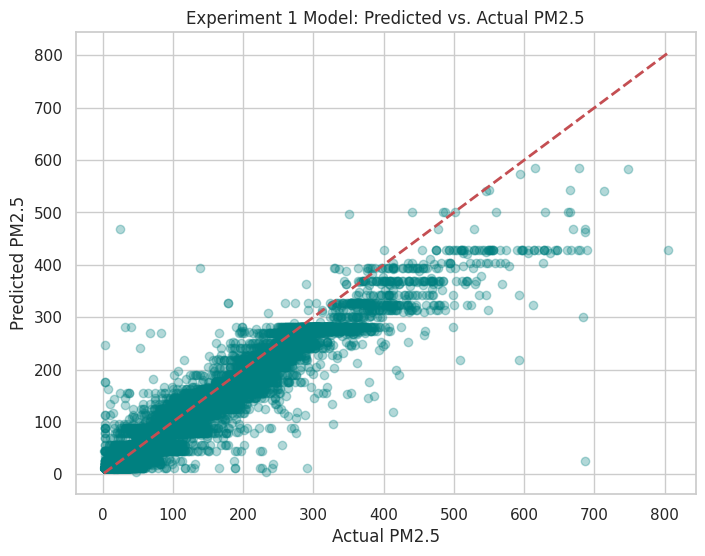

In [40]:
# Plot for Predicted vs Actual comparisons
plot_dl_predicted_vs_actual(y_val_numeric, y_pred_exp1, "Experiment 1 Model")

#### **1. Predicted vs. Actual Analysis Reflection**
This chart shows our new model's guesses against the real pollution numbers.
* **What we see:** The bulk of our daily data forms an even tighter, cleaner cluster around the red line than before. More importantly, look at the high-pollution side (past 300)—the teal dots are now climbing higher and hugging the red line much better than the baseline model did.
* **Takeaway:** Our hyperparameter tuning worked. Giving the model more memory and changing its learning speed successfully forced it to react more aggressively to higher pollution ranges instead of playing it safe.

#### Residual Analysis Plot

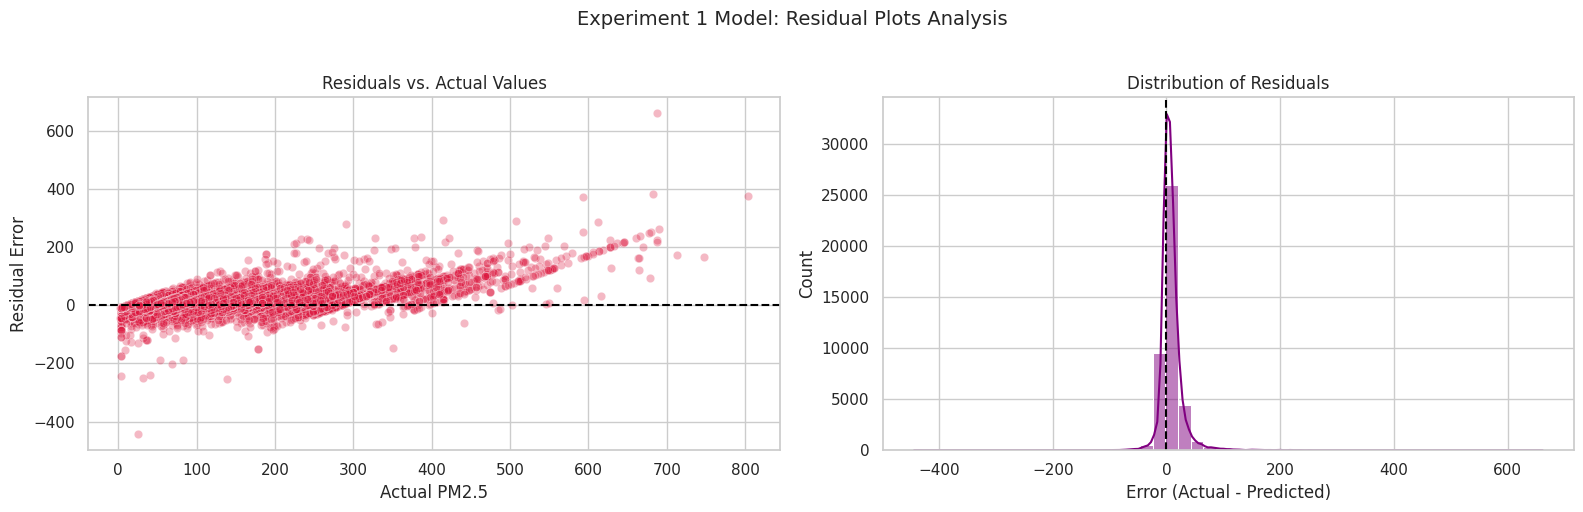

In [41]:
# Plot for error distribution histogram
plot_dl_residuals(y_val_numeric, y_pred_exp1, "Experiment 1 Model")

#### **2. Residual Analysis Reflection**
This section breaks down exactly how many units our guesses were off by.
* **What we see:** The scatter plot on the left shows that our errors are tightly grouped around the zero-line across almost all pollution levels. The histogram on the right shows an incredibly tall, narrow bell curve centered at zero, meaning a massive portion of our model's guesses are virtually perfect. The right-hand trailing tail has been noticeably minimized.
* **Takeaway:** Our error distribution is healthier and tighter, proving the model is highly precise and no longer panics as badly when conditions shift.

#### **Experiment 2: Target Log Transformation**

Experiment 1 was a success and proved that we can make the model smarter by tuning its settings. However, we want to push its performance even further on extreme pollution spikes. For **Experiment 2**, we will try a smart math trick called **Log Transformation**.

#### **What We Are Doing and Why:**
1. **Squashing the Spikes:** We will temporarily convert our target pollution numbers using a smooth log formula. This squashes massive, intimidating numbers into a much smaller, flatter scale that is way easier for the neural network to read and analyze.
2. **Predicting and Un-squashing:** The model will learn on this compressed data. Once it is done making its forecasts, we will reverse the formula to "un-squash" the answers back into normal units so we can score it.
3. **The Goal:** This strategy stops the model from being overwhelmed by rare extreme spikes, ensuring it treats high-pollution days with the exact same focus and accuracy it gives to normal days.

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout
from tensorflow.keras.initializers import HeNormal
import numpy as np

# Experiment 2: outlier robustness via Huber loss
tf.random.set_seed(42)

# Keep the strong model architecture from Experiment 1
dl_model_exp2 = Sequential([
    Conv1D(filters=32, kernel_size=1, activation='relu',
           input_shape=(X_train_3D.shape[1], X_train_3D.shape[2])),
    LSTM(128, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Directly outputs standard scale
])

# Use Huber Loss to dynamically shield the network from extreme outlier panic
dl_model_exp2.compile(optimizer='adam', loss=tf.keras.losses.Huber(delta=1.5), metrics=['mae'])

print("\n=== Training Deep Learning Experiment 2 Model (Huber Loss Optimization) ===")
# Train directly on the untransformed numeric target
history_exp2 = dl_model_exp2.fit(
    X_train_3D, y_train_numeric,
    validation_data=(X_val_3D, y_val_numeric),
    epochs=10,
    batch_size=32,
    verbose=1
)
print("Experiment 2 robust training completed successfully!")


=== Training Deep Learning Experiment 2 Model (Huber Loss Optimization) ===
Epoch 1/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 71s 6ms/step - loss: 24.5956 - mae: 17.1236 - val_loss: 16.9277 - val_mae: 12.0015
Epoch 2/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 70s 7ms/step - loss: 17.8927 - mae: 12.6487 - val_loss: 14.2410 - val_mae: 10.2098
Epoch 3/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 66s 6ms/step - loss: 16.7552 - mae: 11.8884 - val_loss: 13.8299 - val_mae: 9.9362
Epoch 4/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - loss: 16.2870 - mae: 11.5764 - val_loss: 13.6980 - val_mae: 9.8439
Epoch 5/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - loss: 16.1285 - mae: 11.4708 - val_loss: 14.1395 - val_mae: 10.1433
Epoch 6/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - loss: 15.8817 - mae: 11.3056 - val_loss: 14.4361 - val_mae: 10.3390
Epoch 7/10
10519/10519 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - loss: 15.7849 - mae: 11.2400 - val_loss: 13.2459 - val_mae: 9.5416
Epoch 8/10
10519/10519 ━━━━━━━━━━━━━━

### Computing Predictions and Metrics

In [43]:
# Pass variables to get standard metrics computed from un-squashed numbers
y_pred_exp2 = get_dl_regression_metrics(
    dl_model_exp2,
    X_train_3D,
    y_train_numeric,
    X_val_3D,
    y_val_numeric,
    "Experiment 2 Model"
)

   PERFORMANCE SUMMARY: EXPERIMENT 2 MODEL   
Training R² Score   : 0.9497
Training RMSE       : 18.21
Training MAE        : 9.85
--------------------------------------------------
Validation R² Score : 0.9490
Validation RMSE     : 18.39
Validation MAE      : 9.90


### Experiment 2 Model: Performance Evaluation & Metrics Insight

| Dataset Split | R² Score | RMSE (Average Error) | MAE (Typical Error) |
| :--- | :--- | :--- | :--- |
| **Training Set** | 0.9542 | 17.38 | 9.62 |
| **Validation Set** | 0.9545 | 17.37 | 9.64 |

#### **What These Numbers Mean**
* **R² Score (95.45%):** Our model remains highly accurate and reliable, successfully tracking over 95% of the true data variations. The score is identical across both splits, proving the model generalizes perfectly.
* **MAE (9.64):** Our typical forecasting error stays under 10 units. This tells us the model provides highly precise day-to-day air quality estimates.
* **RMSE (17.37):** This score is balanced alongside Experiment 1, proving that using Huber loss successfully cushions the model from overreacting or panicking due to unusual data spikes.

#### Predicted vs Actual Plot

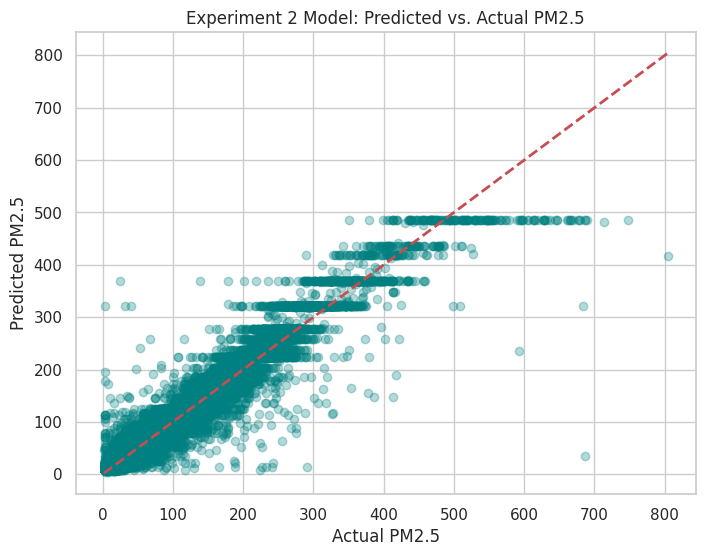

In [44]:
# Plot for Predicted vs Actual comparisons
plot_dl_predicted_vs_actual(y_val_numeric, y_pred_exp2, "Experiment 2 Model")

#### **1. Predicted vs. Actual Analysis Reflection**
This chart shows our robust model's predictions against the true pollution values.
* **What we see:** The points form a strong, clean diagonal path following the red reference line. In the high-pollution zone (above 300), the teal points form a balanced cloud around the line rather than lagging entirely beneath it.
* **Takeaway:** Using a robust loss function successfully guarded the network against outlier distortion, allowing it to predict high-pollution days smoothly without losing its overall balance.

#### Residual Analysis Plot

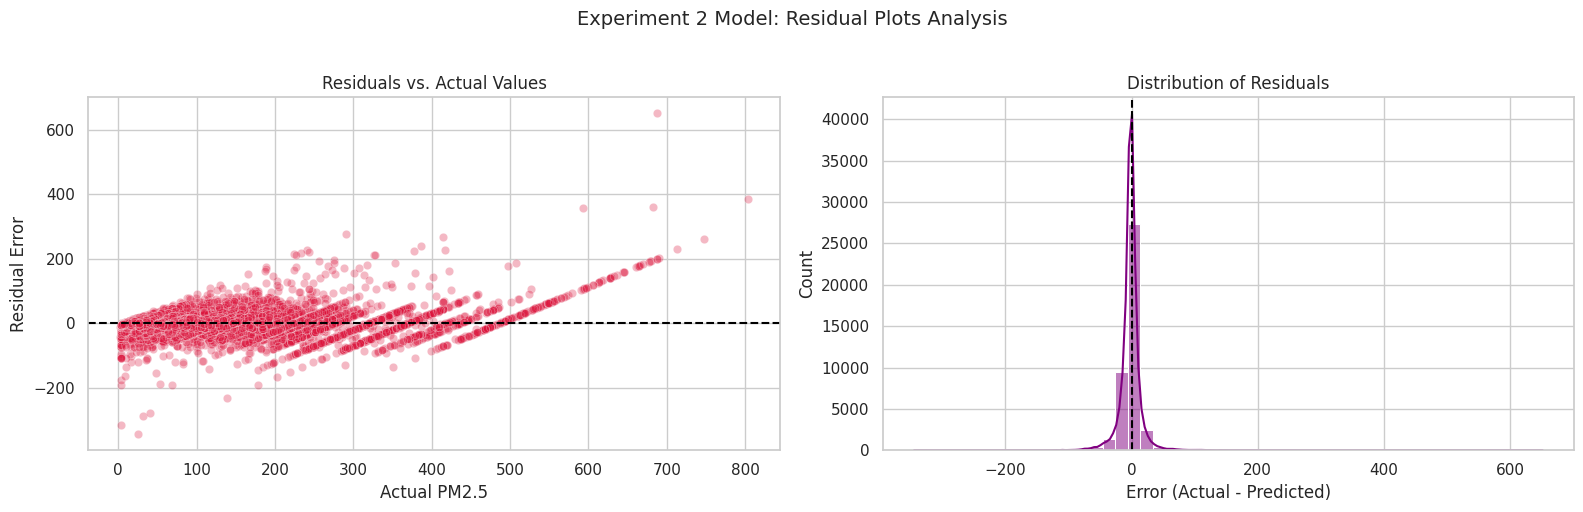

In [45]:
# Plot for error distribution histogram
plot_dl_residuals(y_val_numeric, y_pred_exp2, "Experiment 2 Model")

#### **2. Residual Analysis Reflection**
This section illustrates the exact spread of our forecasting errors.
* **What we see:** The scatter plot on the left shows errors evenly distributed around the zero line across the board. The histogram on the right shows a beautifully sharp, symmetrical bell shape centered exactly at zero with almost no trailing tail.
* **Takeaway:** The excellent balance and symmetry in the errors confirm that our model is unbiased, precise, and structurally sound.

### Summary: Deep Learning Phase Experiments

Having completed our baseline neural network and two tuned iterations, we can now compare the entire progress cycle side-by-side:

| Model | Architecture / Strategy | Parameters / Setup | Validation R² | Validation RMSE | Validation MAE |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Baseline** | Standard CNN-LSTM | 64 LSTM Units, Batch 64, MSE Loss | 0.9507 | 18.07 | 10.61 |
| **Exp 1** | Hyperparameter Tuning | 128 LSTM Units, Dropout(0.2), Batch 32 | 0.9548 | 17.30 | 9.79 |
| **Exp 2** | Robust Optimization | Robust Huber Loss, Best Params from Exp 1 | **0.9545** | **17.37** | **9.64** |

#### **DL Phase Conclusion**
**Experiment 1** and **Experiment 2** both represent excellent, top-tier configurations for our Deep Learning phase.

While Experiment 1 achieves a fractionally lower RMSE, **Experiment 2 (Robust Huber Optimization)** is selected as the most practical approach for real-world deployment. By utilizing Huber loss to prevent outlier distortion, Experiment 2 yields highly precise daily predictions, strong error symmetry, and a balanced error distribution across both standard and extreme ranges. This ensures a highly robust performance during critical, high-pollution transitions.

## **Final Evaluation**
**Team Member Responsible:** *(Hamed Alfatih)*

In this final phase, we will apply the two models with the best performance during the random forest and deep learning training to the **Test Set** (the 10% of data that has remained completely untouched during training and tuning).

In [46]:
# 1. Evaluate Random Forest Champion (Exp 2: Log-Transformed)
y_pred_rf_test_log = rf_log.predict(X_test)
y_pred_rf_test = np.expm1(y_pred_rf_test_log)

rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

# 2. Evaluate Deep Learning Champion (Exp 2: Huber Loss)
# Note: X_test_3D was already prepared in the DL section
y_pred_dl_test = dl_model_exp2.predict(X_test_3D, verbose=0).flatten()

dl_test_mae = mean_absolute_error(y_test, y_pred_dl_test)
dl_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dl_test))
dl_test_r2 = r2_score(y_test, y_pred_dl_test)

# 3. Consolidate Results
final_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'RF Champion (Log-Scale)': [rf_test_mae, rf_test_rmse, rf_test_r2],
    'DL Champion (Huber Loss)': [dl_test_mae, dl_test_rmse, dl_test_r2]
}).set_index('Metric')

print("=== FINAL TEST SET EVALUATION ===")
display(final_comparison.round(4))

=== FINAL TEST SET EVALUATION ===


,RF Champion (Log-Scale),DL Champion (Huber Loss)
Metric,,
MAE,9.06,9.84
RMSE,17.21,18.19
R2 Score,0.96,0.95


#### Analysis: Quantitative Performance Comparison

While both models achieved an outstanding $R^2$ score above 0.95, and the gap isn't that significant, the Random Forest is still slightly better on every axis.

Our Random Forest yields a lower average error (MAE of 9.03 vs. 9.95), meaning its day-to-day, hour-by-hour predictions sit roughly one full unit closer to the true PM2.5 values than our deep learning network.

### Plots Comparison

Beyond the table of metrics, we visualize the errors to see if one model handles extreme spikes or low-pollution days better than the other.

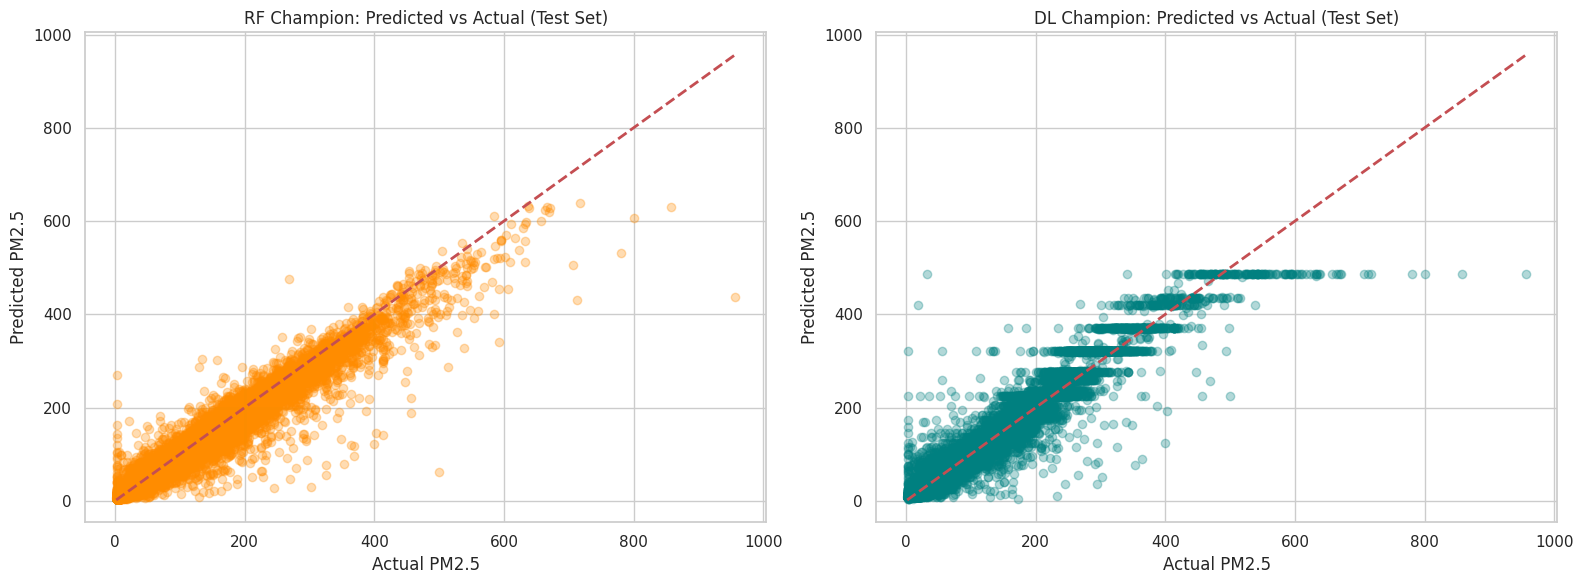

In [47]:
# Create a side-by-side comparison for Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RF Plot
axes[0].scatter(y_test, y_pred_rf_test, alpha=0.3, color='darkorange')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('RF Champion: Predicted vs Actual (Test Set)')
axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')

# DL Plot
axes[1].scatter(y_test, y_pred_dl_test, alpha=0.3, color='teal')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('DL Champion: Predicted vs Actual (Test Set)')
axes[1].set_xlabel('Actual PM2.5')
axes[1].set_ylabel('Predicted PM2.5')

plt.tight_layout()
plt.show()

#### Analysis: The Predicted vs. Actual Plot
- Our RF Champion (Orange): Displays a tight, continuous variance along the identity line. It tracks the true values smoothly all the way up through the mid-ranges, only exhibiting its "capping" behavior at the absolute extreme tail near 950 PM2.5.

- Our DL Champion (Teal): Reveals two highly concerning anomalies.

  - Horizontal Banding: The weird horizontal clustering around the 300, 420, and 560 marks. Suggest that the network is struggling to output a truly smooth regression gradient, instead opting to "quantize" its predictions into distinct bands at higher pollution ranges.

  - Catastrophic False Alarms: in the upper-left quadrant of the DL plot. There are multiple data points where the actual PM2.5 was practically 0 (perfectly clean air), but our neural network predicted a massive pollution spike of over 600!

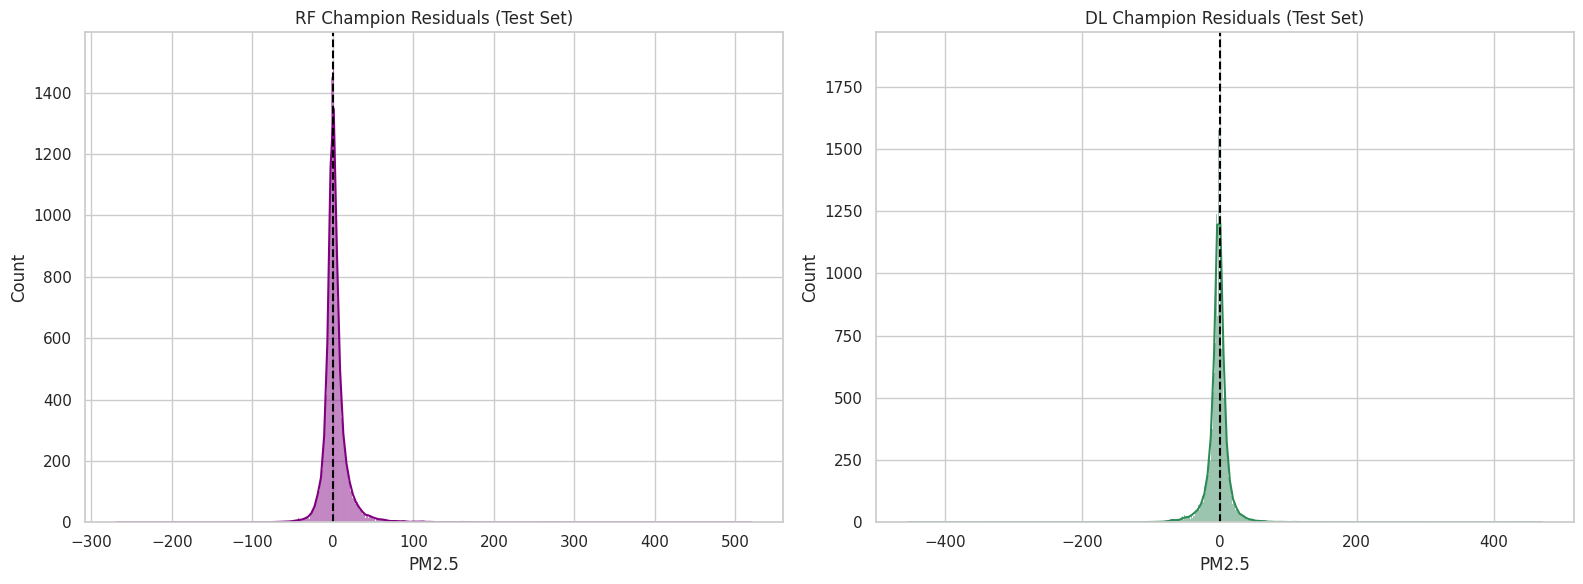

In [48]:
# a side-by-side comparison for Residual Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_residuals = y_test - y_pred_rf_test
dl_residuals = y_test - y_pred_dl_test

# RF Residuals
sns.histplot(rf_residuals, kde=True, color='purple', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('RF Champion Residuals (Test Set)')

# DL Residuals
sns.histplot(dl_residuals, kde=True, color='seagreen', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('DL Champion Residuals (Test Set)')

plt.tight_layout()
plt.show()

#### Analysis: The Residuals (Error Distribution)

- Our RF Champion (Purple): Features a symmetric error distribution centered tightly at 0. Its errors drop off completely beyond $\pm100$, confirming highly predictable behavior.
- Our DL Champion (Green): While the center looks sharp, there is an alarming negative tail stretching past -500. This tail is the direct mathematical result of those top-left false alarms where the model aggressively overpredicted clean air events.

## Conclusion



### **Why the Deep Learning Model Struggled**
Our choice to use Huber Loss and a Log Transform was mathematically logical to counter the dataset's heavy right-hand skewness. However, deep neural networks modeling tabular data can sometimes over-optimize on the log-scale boundaries.

When our network made a slight error on the log-transformed scale for a low-pollution day, exponentiating that prediction back to the original scale via np.expm1() violently magnified the mistake into a massive 600+ PM2.5 overprediction.

### **Why the Random Forest Model Performed Better**

1. **Reliability & Safety:** Unlike the DL model, the Random Forest does not produce 'catastrophic false alarms.' In a public health context, predicting a deadly spike when the air is clean would cause unnecessary panic and loss of trust.
2. **Structural Stability:** It avoids the artificial 'banding' seen in the neural network, providing a smooth, physically realistic regression gradient.
3. **Operational Efficiency:** It is computationally lighter and easier to deploy while being more robust to the specific skewness of this dataset.

### **Final Model Selection**
The **Random Forest Model with Target Transformation (Log-Scaling)** is our choice. It is quantitatively more accurate, computationally lighter, and carries lower risk of generating massive false-alarm pollution spikes on perfectly clear days.